# **Complex Systems: Final Project**
### Chialvo map:

$$
x_{n+1} = f(x_n, y_n) = x_n^2 exp(y_n - x_n) + k \\
y_{n+1} = g(y_n, x_n) = ay_n - b x_n + c 
$$

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import scienceplots
from numpy import float64
from matplotlib.animation import FuncAnimation
from scipy.optimize import fsolve
import os
import multiprocessing as mp
import glob
from PIL import Image

# Define the style
plt.style.use(['science', 'notebook', 'no-latex']) # Use a specific style for figures

# 1. Mapping Neural Excitability

In [2]:
# Define the Chialvo map functions

def xnext(x, y, k):
    """
    Compute the next x value in the Chialvo map.
    """
    return x**2 * np.exp(y - x) + k

def ynext(y, x, a, b, c):   
    """
    Compute the next y value in the Chialvo map.
    """
    return a * y - b * x + c

In [3]:
# y array
y = np.linspace(-1, 5, 100)

# x array
x = np.linspace(-1, 13, 100)

# Define the parameters
a = 0.89
b = 0.6
c = 0.28
k = 0.0

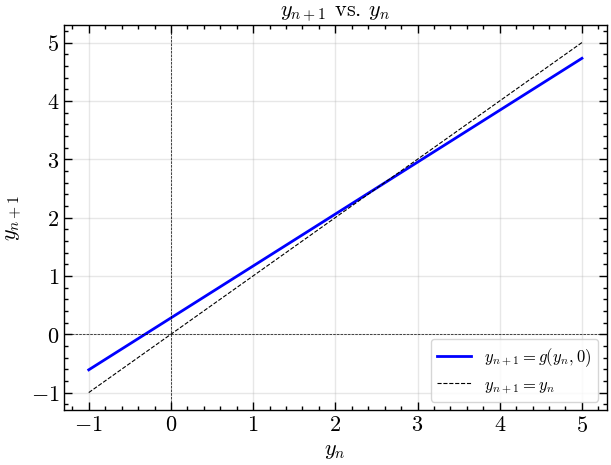

In [4]:
# Plot y_n vs. y_n+1
plt.figure(figsize=(7, 5))
plt.plot(y, ynext(y, 0, a, b, c), label=r'$y_{n+1} = g(y_n, 0)$', color='blue')
plt.plot(y, y, label=r'$y_{n+1} = y_n$', color='black', ls='--', lw=0.8)
plt.title(r'$y_{n+1}$ vs. $y_n$')
plt.xlabel(r'$y_n$')
plt.ylabel(r'$y_{n+1}$')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

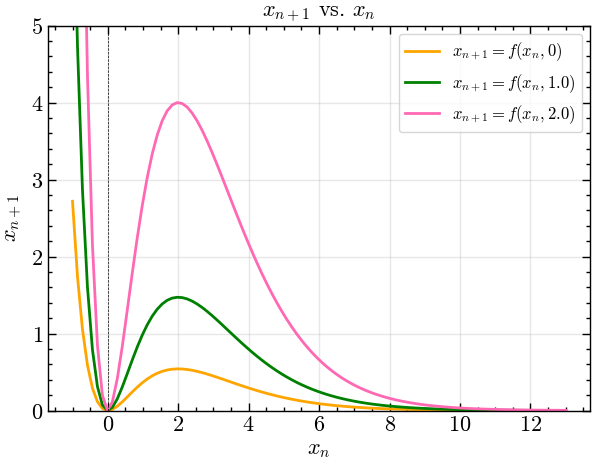

In [5]:
# Plot y_n vs. y_n+1
plt.figure(figsize=(7, 5))
plt.plot(x, xnext(x, 0, k), label=r'$x_{n+1} = f(x_n, 0)$', color='orange')
plt.plot(x, xnext(x, 1.0, k), label=r'$x_{n+1} = f(x_n, 1.0)$', color='green')
plt.plot(x, xnext(x, 2.0, k), label=r'$x_{n+1} = f(x_n, 2.0)$', color='hotpink')
plt.title(r'$x_{n+1}$ vs. $x_n$')
plt.xlabel(r'$x_n$')
plt.ylabel(r'$x_{n+1}$')
plt.ylim(0, 5)
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

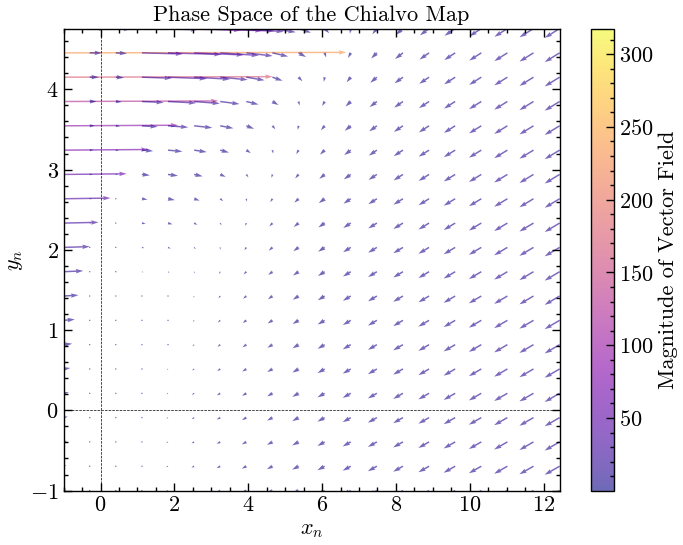

In [6]:
X, Y = np.meshgrid(x, y)
U = xnext(X, Y, k) - X
V = ynext(Y, X, a, b, c) - Y
# Compute module of vectors
magnitude = np.sqrt(U**2 + V**2)


# Interpolate for better visualization
fac_reduction = 5
new_x = x[::fac_reduction]
new_y = y[::fac_reduction]
grid_x, grid_y = np.meshgrid(new_x, new_y)
U_interp = griddata((X.flatten(), Y.flatten()), U.flatten(), (grid_x, grid_y), method='cubic')
V_interp = griddata((X.flatten(), Y.flatten()), V.flatten(), (grid_x, grid_y), method='cubic')
magnitude = np.sqrt(U_interp**2 + V_interp**2)

plt.figure(figsize=(8, 6))
plt.quiver(grid_x, grid_y, U_interp, V_interp, magnitude, cmap='plasma', alpha=0.6)
plt.title('Phase Space of the Chialvo Map')
plt.xlabel(r'$x_n$')
plt.ylabel(r'$y_n$')
plt.xlim(new_x.min(), new_x.max())
plt.ylim(new_y.min(), new_y.max())
plt.colorbar(label='Magnitude of Vector Field')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
#plt.grid(alpha=0.3)
plt.show()

### Bifurcation diagram

$y$ is virtually frozen ($x=0$), then:

$$
y_{f0} = r= \frac{c}{1-a},
$$

A perturbation in x is essentially described by the iteration map:

$$
x_{n+1} = x_n^2exp(r - x_n)
$$


In [7]:
# Bifurcation diagram for x_n

def xnext_bifurcation(x, r):
    return x**2 * np.exp(r - x)

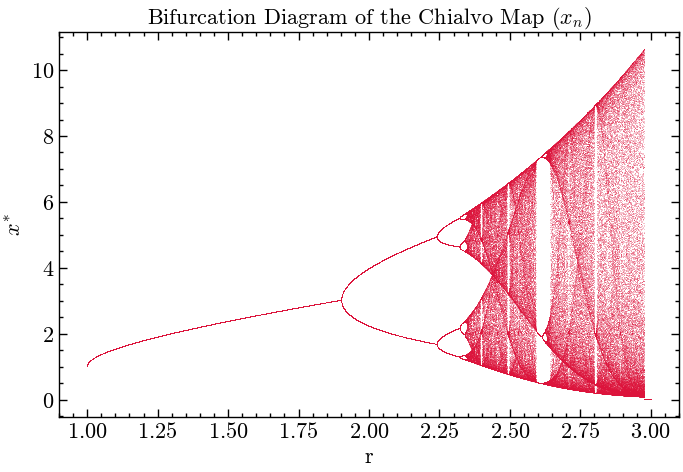

In [8]:
# Define n 
n = 5000

# Define r range
r = np.linspace(1.0, 3., n)

# Define initial x_n
x_n = 1.2 * np.ones(n)

# Define iterations and last
iterations = 1000
last = 100

plt.figure(figsize=(8, 5))
for i in range(iterations):
    x_n = xnext_bifurcation(x_n, r)
    if i >= (iterations - last):
        plt.plot(r, x_n, alpha=0.25, color='crimson', marker=',', linestyle='None')

plt.title(r'Bifurcation Diagram of the Chialvo Map ($x_n$)')
plt.xlabel('r')
plt.ylabel(r'$x^{*}$')
plt.show()

Let's analize the case $k=0$. Then, the equations

$$
x_{n+1} = f(x_n, y_n) = x_n^2 exp(y_n - x_n) + k \\
y_{n+1} = g(y_n, x_n) = ay_n - b x_n + c 
$$

can be written as: (...)




In [244]:
class ChialvoMap:
    def __init__(self, a=0.89, b=0.6, c=0.28, k=0.025, T=1000):
        self.a = a
        self.b = b
        self.c = c
        self.k = k
        self.T = T
        self.trajectory = []

    def step(self, x, y):
        x_new = x**2 * np.exp(y - x) + self.k
        y_new = self.a * y - self.b * x + self.c

        return np.array([x_new, y_new], dtype=float64)

    def run(self, x0=0.0, y0=0.0):     
        self.trajectory.append([x0, y0])

        for t in range(self.T):
            self.trajectory.append(self.step(x0, y0))
            x0, y0 = self.trajectory[-1]
                
        return np.array(self.trajectory, dtype=float64)

    def plot_trajectory(self):
        plt.plot(self.trajectory[:, 0], self.trajectory[:, 1])
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Chialvo Map Trajectory')
        plt.grid(alpha=0.3)
        plt.show()

In [10]:
chialvo = ChialvoMap(T=50, a = 0.89, b = 0.6, c = 0.28, k = 0.02)
trajectory = chialvo.run(x0=0.09, y0=2.54)

In [118]:
# Nullclines and fixed points
def nullcline_x(x, k=0.02):
    y = np.log((x - k) / (x**2)) + x
    return y

def nullcline_y(x, a = 0.89, b = 0.6, c = 0.28):
    y = (c - b * x) / (1 - a)
    return y

/tmp/ipykernel_42983/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


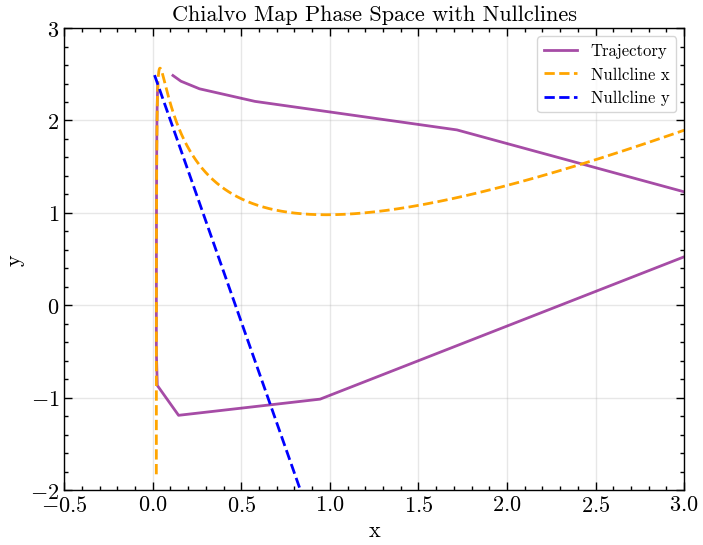

In [12]:
# Phase space with nullclines
x_null = np.linspace(0.01, 5, 60000)
nclinex = nullcline_x(x_null)
ncliney = nullcline_y(x_null)

plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], label='Trajectory', color='purple', alpha=0.7)
plt.plot(x_null, nclinex, label='Nullcline x', color='orange', ls='--')
plt.plot(x_null, ncliney, label='Nullcline y', color='blue', ls='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlim(-0.5, 3.0)
plt.ylim(-2, 3)
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.show()

This plot reveals the mechanism behind the action potential. It's not just a pulse in time; it's a structured loop in state space, driven by the interplay between the fast activation variable ($x$) and the slow recovery variable ($y$). The N-shaped X-nullcline is the classic feature of excitable systems that enables this behavior.

**Nullclide:** The focus of point with null derivatives for each state variable. 

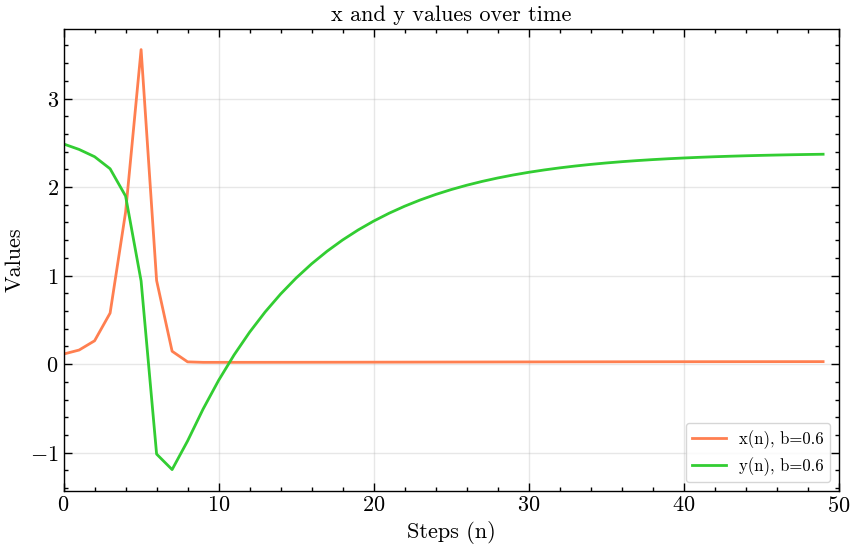

In [13]:
# plot steps vs. x and y values
fig = plt.figure(figsize=(10, 6))

b_val = np.linspace(0.2, 0.8, 1000)

# Color gradient for values of b
colors_1 = plt.cm.viridis(np.linspace(0, 1, len(b_val)))
colors_2 = plt.cm.plasma(np.linspace(0, 1, len(b_val)))
colors = np.vstack((colors_1, colors_2)) 

# for i, b in enumerate(b_val):
#     chialvo_plot = ChialvoMap(T=100, a = 0.89, b = b, c = 0.28, k = 0.02)
#     trajectory = chialvo_plot.run(x0=0.09, y0=2.54)
#     plt.plot(trajectory[:, 0], color=colors_1[i])
#     plt.plot(trajectory[:, 1], color=colors_2[i])

# b = 0.6 highlight
plt.plot(trajectory[:, 0], color='coral', linewidth=2, label=f'x(n), b={0.6}')
plt.plot(trajectory[:, 1], color='limegreen', linewidth=2, label=f'y(n), b={0.6}')  
plt.title('x and y values over time')
#Add colorbar
# sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=b_val.min(), vmax=b_val.max()))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=plt.gca())
# cbar.set_label('b values')
plt.legend(frameon=True, fontsize=12, loc ='lower right')
plt.xlim(0, 50)
plt.xlabel('Steps (n)')
plt.ylabel('Values')
plt.grid(alpha=0.3)
plt.show()

I already show that $x_f=0$ is a fixed point, so we set the IC of the y (recovery) variable to its fixed value and we vary a litle bit x to see how the system evolves.
This example is very good to exlain this system because there we saw how the x variable respresents the action potential (like a neuron's spike). The variable that decreases and then slowly recovers is the recovery variable.

Notice lso the effect of the parameter $b$ which controls how strongly $x_n$ drives $y_n$ down. 

FInally, the recovery happes a rate of a. Just take a look to the equations and you will see it.

# 2. Phase Plane and Qualitative Solutions

X-nullclide:

$$
y = ln(x-k) - 2 ln(x) + x,
$$

Y-nullclide:

$$
x = \frac{(a-1)y + c}{b}
$$

In [14]:
# Phase space with nullclines
x_for_nullX = np.linspace(-0.0201, 5, 100000)
x_for_nullY = np.linspace(-0.2, 5, 100000)
dx = nullcline_x(x_for_nullX, k=0.02)
dy = nullcline_y(x_for_nullY, a=0.89, b=0.6, c=0.28)

/tmp/ipykernel_42983/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


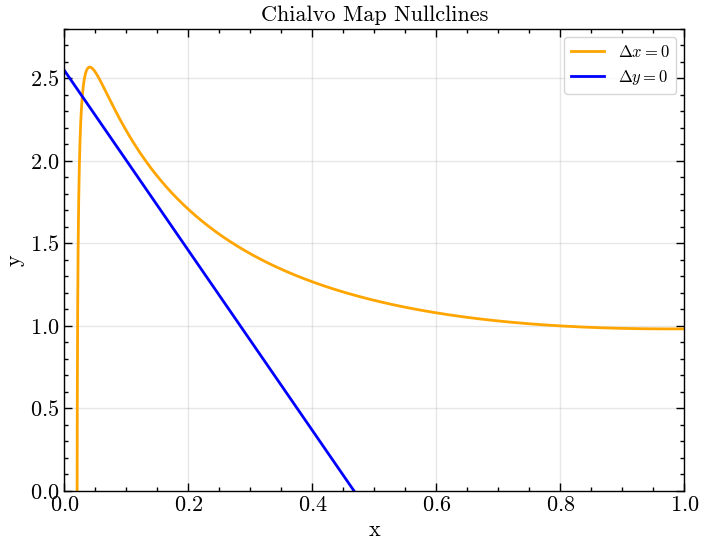

In [15]:
# Plot nullclines
plt.figure(figsize=(8, 6))
plt.plot(x_for_nullX, dx, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='blue')
plt.title('Chialvo Map Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0., 1.)
plt.ylim(0, 2.8)
plt.legend(frameon=True, fontsize=12)
plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_42983/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


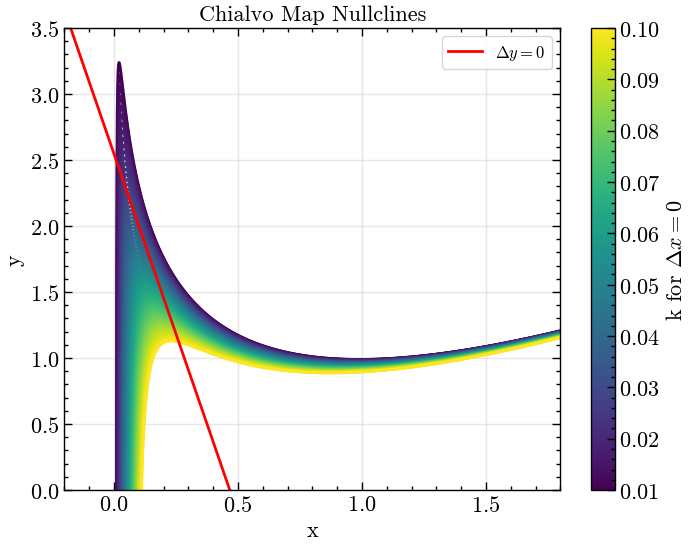

In [16]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Define k values
k_values = np.arange(0.01, 0.1, 0.001)
# k_values = [0.01, 0.04, 0.08, 0.1]

# cmap for k 
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(k_values)))

for k, color in zip(k_values, colors):
    dx = nullcline_x(x_for_nullX, k=k)
    plt.plot(x_for_nullX, dx, color=color)
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='red')

plt.title('Chialvo Map Nullclines')
plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-0.2, 1.8)
plt.ylim(0.0, 3.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=k_values.min(), vmax=k_values.max()))
sm.set_array([])
plt.colorbar(sm, label='k for ' + r'$\Delta x = 0$' , ax=plt.gca())

plt.legend(frameon=True, fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Parameters for nullclides with three intersections:

In [17]:
# Phase space with nullclines
x_for_nullX = np.linspace(-0.0201, 5, 100000)
x_for_nullY = np.linspace(-0.2, 5, 100000)
dx = nullcline_x(x_for_nullX, k=0.02)
dy = nullcline_y(x_for_nullY, a=0.89, b=0.3, c=0.26)

/tmp/ipykernel_42983/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


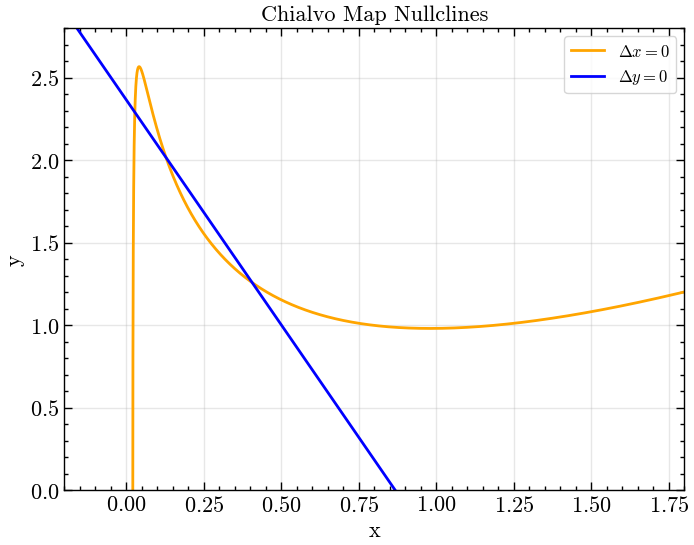

In [18]:
# Plot nullclines
plt.figure(figsize=(8, 6))
plt.plot(x_for_nullX, dx, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='blue')
plt.title('Chialvo Map Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.2, 1.8)
plt.ylim(0, 2.8)
plt.legend(frameon=True, fontsize=12)
plt.grid(alpha=0.3)
plt.show()


## 2.1 Non-autonomous solutions: excitable dynamics

Increasing $k$ in this model can be equivalent to a bias current applied to a nerve cell that progressively depolarizes its membrane potential.

Why nullcline are important?

- The system rests at the nullclines' intersections and may response to a proper perturbation with an action potential.

- The quiescent-excitable regime will exist as long as nullclines intersect to the left of the
X-nullcline maxima.

- It is seen that increasing $k$ decreases the negative slope of the X-nullcline, which (for other parameters fixed) shifts the nullclines’ intersection towards conditions where the fixed point loses stability and oscillatory solutions appears.

### 2.1.1 Normal and supernormal excitability




In [19]:
# Phase space with nullclines
x_for_nullX = np.linspace(-0.0201, 1., 100000)
x_for_nullY = np.linspace(0, 1., 100000)
dx = nullcline_x(x_for_nullX, k=0.02)
dy = nullcline_y(x_for_nullY, a=0.89, b=0.6, c=0.28)

# Intersection points
from scipy.optimize import fsolve
def equations(p):
    # Define parameters
    k = 0.02
    a = 0.89
    b = 0.6
    c = 0.28

    x, y = p
    return (np.log(x-k) - 2 * np.log(x) + x - y,
            (y*(a-1)+c)/(b) - x) 

initial_guesses = [(0.03, 2.39)]

fixed_points = []
for guess in initial_guesses:
    fixed_point = fsolve(equations, guess)
    fixed_points.append(fixed_point)   

/tmp/ipykernel_42983/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


In [20]:
print("Fixed Points (x, y):")
for point in fixed_points:
    print(point)

Fixed Points (x, y):
[0.0287569  2.38859872]


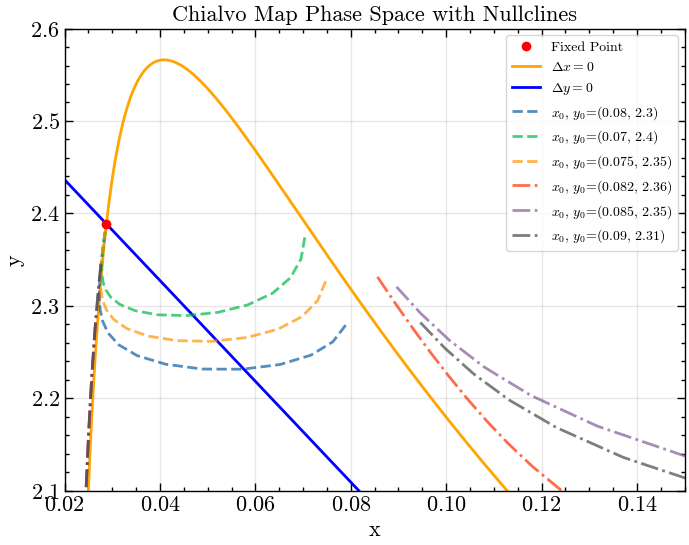

In [21]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Plot fixed points
for point in fixed_points:
    plt.plot(point[0], point[1], 'ro', label='Fixed Point', zorder=5)

# Plot nullclines
plt.plot(x_for_nullX, dx, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY, dy, label=r'$\Delta y = 0$', color='blue')

# Phase space for diffrent initial conditions
ics_st = [(0.08, 2.3), (0.07, 2.4), (0.075, 2.35)] # superthreshold
ics_ap = [(0.082, 2.36), (0.085, 2.35), (0.09, 2.31)] # action potential

for ic in ics_st:
    chialvo = ChialvoMap(T=50, a = 0.89, b = 0.6, c = 0.28, k = 0.02)
    trajectory = chialvo.run(x0=ic[0], y0=ic[1])
    plt.plot(trajectory[:, 0], trajectory[:, 1], linestyle='--',
             label=r'$x_{0}, \, y_{0}$=' + f'{ic}', alpha=0.7)
    
for ic in ics_ap:
    chialvo = ChialvoMap(T=50, a = 0.89, b = 0.6, c = 0.28, k = 0.02)
    trajectory = chialvo.run(x0=ic[0], y0=ic[1])
    plt.plot(trajectory[:, 0], trajectory[:, 1], linestyle='-.',
             label=r'$x_{0}, \, y_{0}$=' + f'{ic}', alpha=0.7)

plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(2.10, 2.6)
plt.xlim(0.02, 0.15)
plt.legend(frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.show()

For this initial conditions the transition is not perfect binary switch (cotinuous gradation). The reason lies in the phase space geomtry of a 2D excitable systems with a single fixes point (this is generic for systems with a single interseccion of the nullclides.) In this case we saw:
- Perturbations that land just to the left of this region decay quickly back to rest.

- Perturbations that land just to the right of this region initiate a full action potentia

In [245]:
# Define parameters
a_f6 = 0.89
b_f6 = 0.6
c_f6 = 0.28
k_f6 = 0.02

# Define initial conditions
x0_f6 = np.arange(0.0852, 0.0853, 1e-7)

# y0 fixed at the fixed point y value
y0_f6 = np.ones(len(x0_f6)) * fixed_points[0][1]

chialvo_f6 = ChialvoMap(T=50, a = a_f6, b = b_f6, c = c_f6, k = k_f6)
trajectory_f6 = chialvo_f6.run(x0=x0_f6, y0=y0_f6)

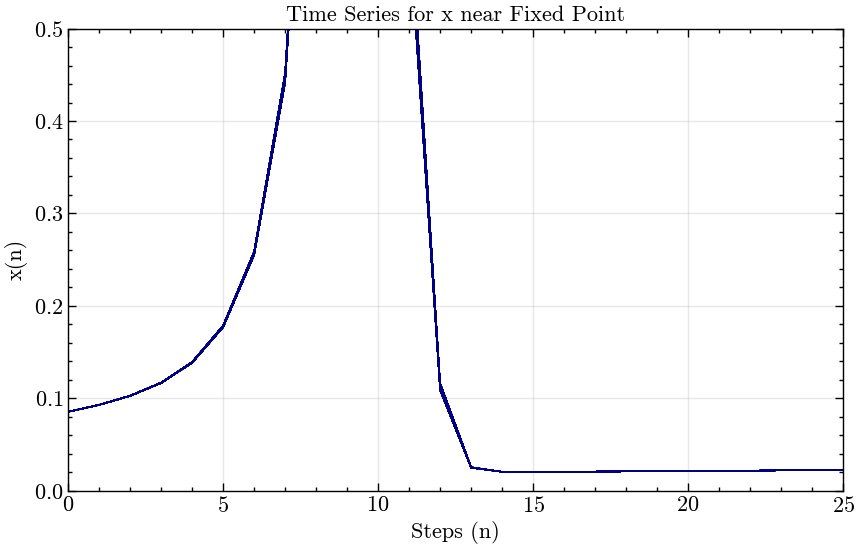

In [246]:
# Time series for x
plt.figure(figsize=(10, 6))
for i in range(len(x0_f6)):
    plt.plot(trajectory_f6[:, 0, :].T[i], color='navy', linewidth=0.8)
plt.title('Time Series for x near Fixed Point')
plt.xlabel('Steps (n)')
plt.ylabel('x(n)')
plt.xlim(0, 25)
plt.ylim(0.0, 0.5)
plt.grid(alpha=0.3)
plt.show()

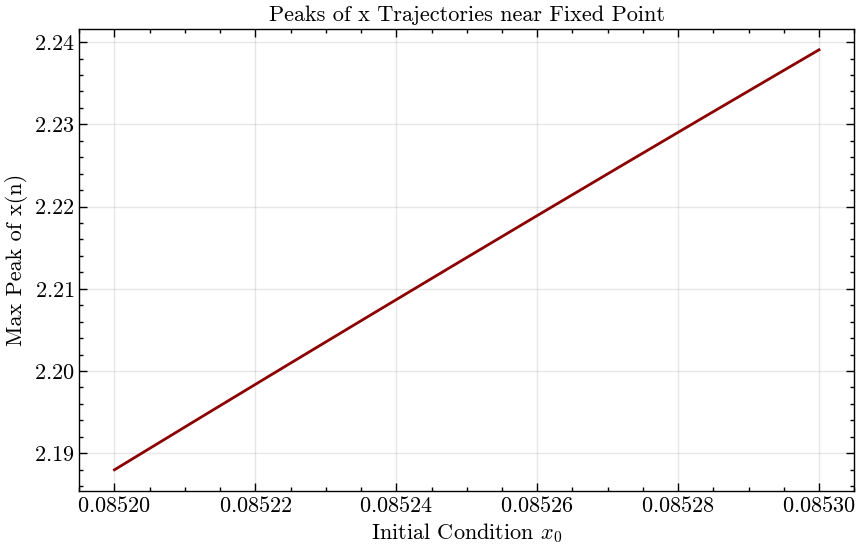

In [191]:
# Plot the peaks of each trajectory
plt.figure(figsize=(10, 6))
max_peaks = np.max(trajectory_f6[:, 0, :].T, axis=1)
plt.plot(x0_f6, max_peaks, color='darkred')
plt.title('Peaks of x Trajectories near Fixed Point')
plt.xlabel(r'Initial Condition $x_0$')
plt.ylabel('Max Peak of x(n)')
plt.grid(alpha=0.3)
plt.show()

#### Dampened oscillatory decay to equilibrium 

In [247]:
# Define parameters
a_f7 = 0.89
b_f7 = 0.6
c_f7 = 0.28
k_f7 = 0.029

# Phase space with nullclines
x_for_nullX_f7 = np.linspace(0.04, 1., 100000)
x_for_nullY_f7 = np.linspace(0.04, 1., 100000)
dx_f7 = nullcline_x(x_for_nullX_f7, k=k_f7)
dy_f7 = nullcline_y(x_for_nullY_f7, a=a_f7, b=b_f7, c=c_f7)

# Intersection points
from scipy.optimize import fsolve
def equations(p):
    # Define parameters
    k = 0.029
    a = 0.89
    b = 0.6
    c = 0.28

    x, y = p
    return (np.log(x-k) - 2 * np.log(x) + x - y,
            (y*(a-1)+c)/(b) - x) 

initial_guesses = [(0.06, 2.20)]

fixed_points_f7 = []
for guess in initial_guesses:
    fixed_point = fsolve(equations, guess)
    fixed_points_f7.append(fixed_point)   

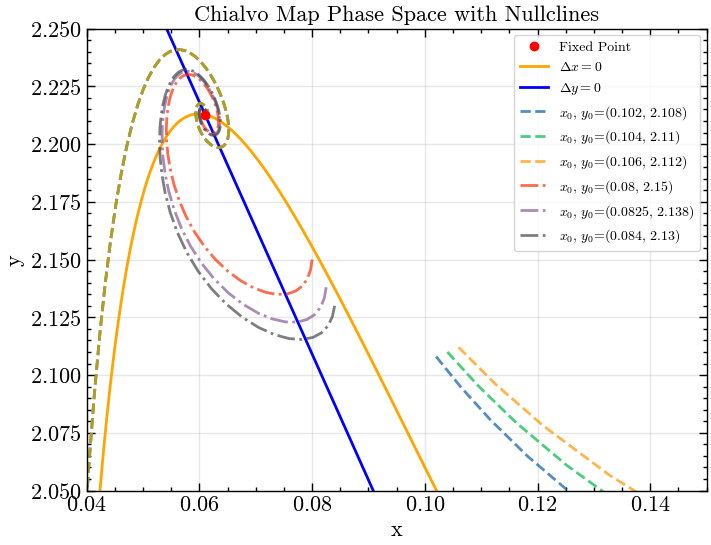

In [248]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Plot fixed points
for point in fixed_points_f7:
    plt.plot(point[0], point[1], 'ro', label='Fixed Point', zorder=5)

# Plot nullclines
plt.plot(x_for_nullX_f7, dx_f7, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY_f7, dy_f7, label=r'$\Delta y = 0$', color='blue')

# Phase space for diffrent initial conditions
ics_st = [(0.08, 2.150), (0.0825, 2.138), (0.084, 2.130)] # subthreshold
ics_ap = [(0.102, 2.108), (0.104, 2.110), (0.106, 2.112)] # action potential

for ic in ics_ap:
    chialvo_f7 = ChialvoMap(T=200, a = a_f7, b = b_f7, c = c_f7, k = k_f7)
    trajectory = chialvo_f7.run(x0=ic[0], y0=ic[1])
    plt.plot(trajectory[:, 0], trajectory[:, 1], linestyle='--',
             label=r'$x_{0}, \, y_{0}$=' + f'{ic}', alpha=0.7)
    
for ic in ics_st:
    chialvo_f7 = ChialvoMap(T=200, a = a_f7, b = b_f7, c = c_f7, k = k_f7)
    trajectory = chialvo_f7.run(x0=ic[0], y0=ic[1])
    plt.plot(trajectory[:, 0], trajectory[:, 1], linestyle='-.',
             label=r'$x_{0}, \, y_{0}$=' + f'{ic}', alpha=0.7)

plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(2.05, 2.25)
plt.xlim(0.04, 0.15)
plt.legend(frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [249]:
# Define initial conditions
x0_f7 = np.arange(0.23, 0.30, 0.015)

# y0 fixed at the fixed point y value
y0_f7 = np.ones(len(x0_f7)) * fixed_points_f7[0][1]

chialvo_f7 = ChialvoMap(T=50, a = a_f7, b = b_f7, c = c_f7, k = k_f7)
trajectory_f7 = chialvo_f7.run(x0=x0_f7, y0=y0_f7)

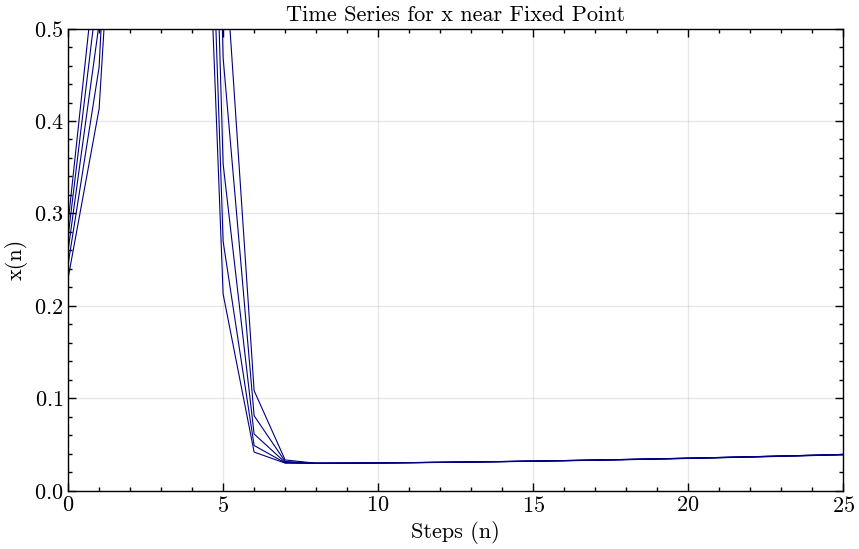

In [250]:
# Time series for x
plt.figure(figsize=(10, 6))
for i in range(len(x0_f7)):
    plt.plot(trajectory_f7[:, 0, :].T[i], color='navy', linewidth=0.8)
plt.title('Time Series for x near Fixed Point')
plt.xlabel('Steps (n)')
plt.ylabel('x(n)')
plt.xlim(0, 25)
plt.ylim(0.0, 0.5)
plt.grid(alpha=0.3)
plt.show()

Initial conditions at the rigth of the X-nullclide dome results in action potentials, while initial conditions at the left decays to the resting point (this is a stable). The aproach to the resting point follows a oscillatory pattern (the resting point is a stable focus).

In [251]:
class ChialvoMap_ext:
    def __init__(self, a=0.89, b=0.6, c=0.28, k=0.025, T=1000):
        self.a = a
        self.b = b
        self.c = c
        self.k = k
        self.T = T
        self.trajectory = []

    def step(self, x, y):
        x_new = x**2 * np.exp(y - x) + self.k
        y_new = self.a * y - self.b * x + self.c

        return np.array([x_new, y_new], dtype=float64)

    def run(self, x0=0.0, y0=0.0, n_ext=None, x_ext=0.015):     
        self.trajectory.append([x0, y0])

        for t in range(self.T):
            if n_ext is not None and t == n_ext:
                x0 += x_ext
            self.trajectory.append(self.step(x0, y0))
            x0, y0 = self.trajectory[-1]
                
        return np.array(self.trajectory, dtype=float64)

    def plot_trajectory(self):
        plt.plot(self.trajectory[:, 0], self.trajectory[:, 1])
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Chialvo Map Trajectory')
        plt.grid(alpha=0.3)
        plt.show()

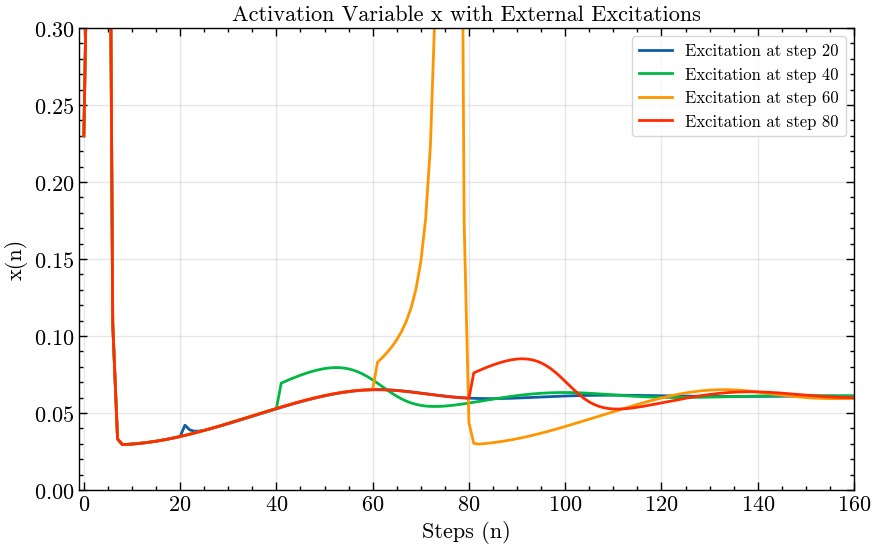

In [258]:
# Plot the activation variables (excitation at steps)
plt.figure(figsize=(10, 6))

N_ext = [20, 40, 60, 80]  # Steps at which external excitation is applied

for n_ext in N_ext:
    chialvo_ext = ChialvoMap_ext(T=160, a = a_f7, b = b_f7, c = c_f7, k = k_f7)
    trajectory_ext = chialvo_ext.run(x0=0.23, y0=fixed_points_f7[0][1], n_ext=n_ext, x_ext=0.015)
    plt.plot(trajectory_ext[:, 0], label=f'Excitation at step {n_ext}')
plt.title('Activation Variable x with External Excitations')
plt.xlabel('Steps (n)')
plt.ylabel('x(n)')
plt.xlim(-1.0, 160)
plt.ylim(0.0, 0.3)
plt.legend(frameon=True, fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In biological experiments this phenomena is investigated by initiating an action potential and then testing the effects of fixed amplitude perturbations applied at various delays after the action potential (Chialvo, 19..).

The important thing here is notice that surprisingly, a smaller-than-normal stimulus can trigger a second spike.

Notice that the occurrence of the action potential coincide with the small oscillation overshoot in the x-variable. In contrast, under normal recovery of excitability, a second action potential can be elicited only up to a given minimum delay while shorter test intervals results always in subthreshold responses.

## 2.2 Autonomous solutions: oscillatory dynamics

Fot $k=0.03$ the nullclines intersect near the negative slope region of X-nullclide and result in a stable focus and a stable oscillatory solution.

In [272]:
# Define parameters
a_f8 = 0.89
b_f8 = 0.6
c_f8 = 0.28
k_f8 = 0.03

# Phase space with nullclines
x_for_nullX_f8 = np.linspace(0.04, 1., 100000)
x_for_nullY_f8 = np.linspace(0.04, 1., 100000)
dx_f8 = nullcline_x(x_for_nullX_f8, k=k_f8)
dy_f8 = nullcline_y(x_for_nullY_f8, a=a_f8, b=b_f8, c=c_f8)

# Intersection points
from scipy.optimize import fsolve
def equations(p):
    # Define parameters
    k = 0.03
    a = 0.89
    b = 0.6
    c = 0.28

    x, y = p
    return (np.log(x-k) - 2 * np.log(x) + x - y,
            (y*(a-1)+c)/(b) - x) 

initial_guesses = [(0.07, 2.19)]

fixed_points_f8 = []
for guess in initial_guesses:
    fixed_point = fsolve(equations, guess)
    fixed_points_f8.append(fixed_point)   

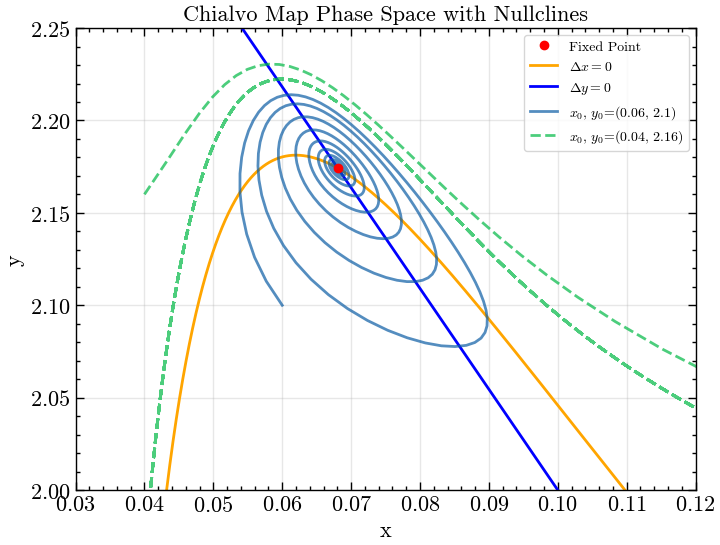

In [ ]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Plot fixed points
for point in fixed_points_f8:
    plt.plot(point[0], point[1], 'ro', label='Fixed Point', zorder=5)

# Plot nullclines
plt.plot(x_for_nullX_f8, dx_f8, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY_f8, dy_f8, label=r'$\Delta y = 0$', color='blue')

# Phase space for diffrent initial conditions
ics_f8 = [(0.06, 2.10), (0.04, 2.16)]

chialvo_f8 = ChialvoMap(T=600, a = a_f8, b = b_f8, c = c_f8, k = k_f8)
trajectory_FP = chialvo_f8.run(x0=ics_f8[0][0], y0=ics_f8[0][1])
plt.plot(trajectory_FP[:, 0], trajectory_FP[:, 1], linestyle='-',
            label=r'$x_{0}, \, y_{0}$=' + f'{ics_f8[0]}', alpha=0.7)

chialvo_f8 = ChialvoMap(T=600, a = a_f8, b = b_f8, c = c_f8, k = k_f8)
trajectory_LC = chialvo_f8.run(x0=ics_f8[1][0], y0=ics_f8[1][1])
plt.plot(trajectory_LC[:, 0], trajectory_LC[:, 1], linestyle='--',
            label=r'$x_{0}, \, y_{0}$=' + f'{ics_f8[1]}', alpha=0.7)

plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(2.0, 2.25)
plt.xlim(0.03, 0.12)
plt.legend(frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.show()

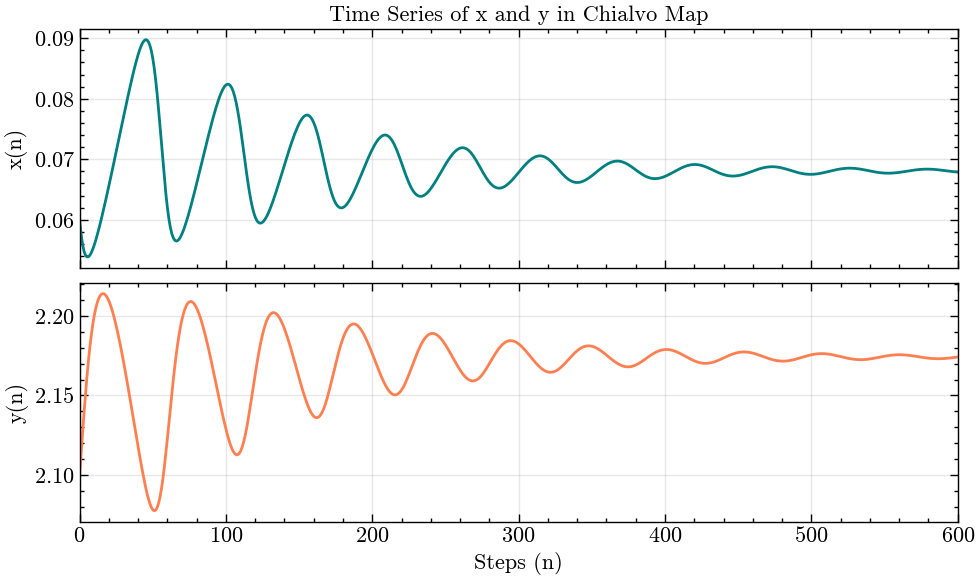

In [279]:
# Two-panel figure of time series of x and y
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(trajectory_FP[:, 0], color='teal')
ax1.set_ylabel('x(n)')
ax1.set_title('Time Series of x and y in Chialvo Map')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 600)

ax2.plot(trajectory_FP[:, 1], color='coral')
ax2.set_xlabel('Steps (n)')
ax2.set_ylabel('y(n)')
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 600)

plt.tight_layout()
plt.show()

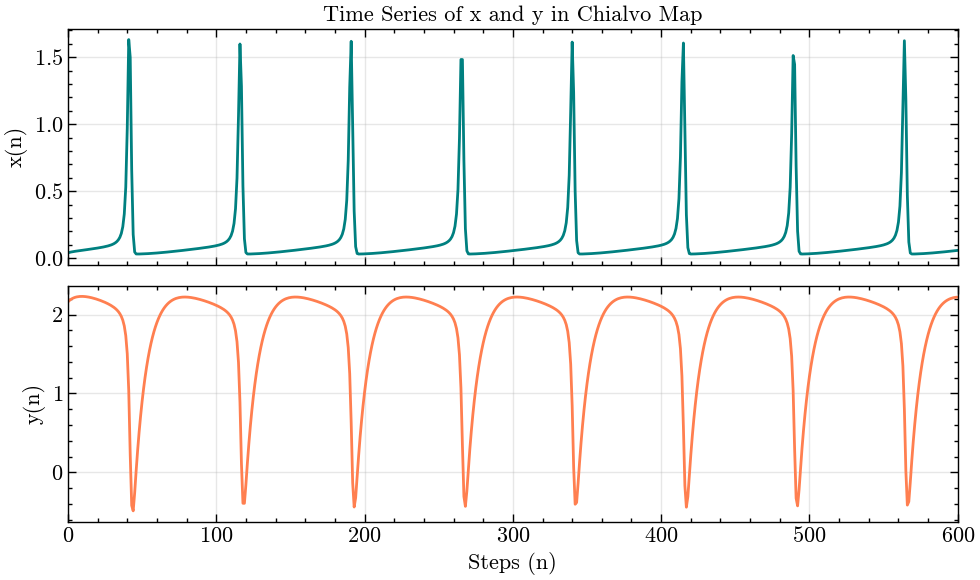

In [280]:
# Two-panel figure of time series of x and y
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(trajectory_LC[:, 0], color='teal')
ax1.set_ylabel('x(n)')
ax1.set_title('Time Series of x and y in Chialvo Map')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 600)

ax2.plot(trajectory_LC[:, 1], color='coral')
ax2.set_xlabel('Steps (n)')
ax2.set_ylabel('y(n)')
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 600)

plt.tight_layout()
plt.show()

The coexistence of this two atractors implies that it is possible to switch between this two solutions applying  single perturbation at the time and amplitud correct. 

This phenomena is called 'annihilation'. It has been reproduced in various experimental settings, including squid giant axons, cardiac Purkinje fibers, and sinus node cells and numerically in model of nerve and cardiac cells [1, 6,14,15].

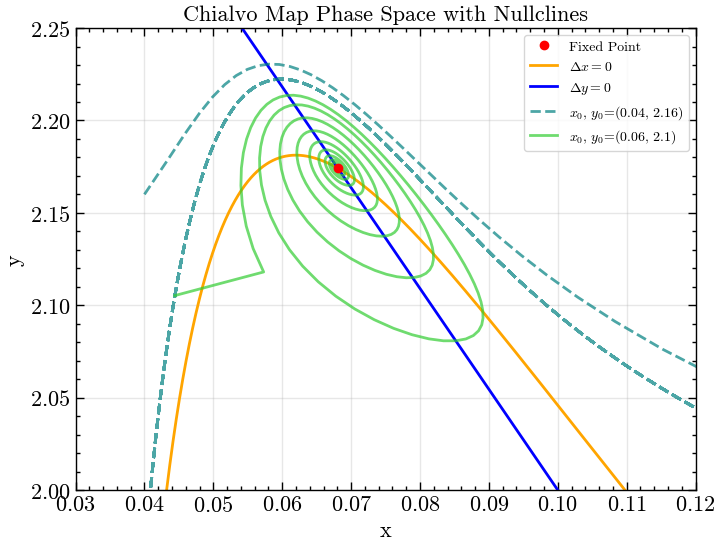

In [326]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Plot fixed points
for point in fixed_points_f8:
    plt.plot(point[0], point[1], 'ro', label='Fixed Point', zorder=5)

# Plot nullclines
plt.plot(x_for_nullX_f8, dx_f8, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY_f8, dy_f8, label=r'$\Delta y = 0$', color='blue')

# Phase space for diffrent initial conditions
ics_f8 = [(0.06, 2.10), (0.04, 2.16)]

# First trajectory without excitation
chialvo_f8 = ChialvoMap_ext(T=600, a = a_f8, b = b_f8, c = c_f8, k = k_f8)
trajectory_LC = chialvo_f8.run(x0=ics_f8[1][0], y0=ics_f8[1][1])
plt.plot(trajectory_LC[:, 0], trajectory_LC[:, 1], linestyle='--',
            label=r'$x_{0}, \, y_{0}$=' + f'{ics_f8[1]}', alpha=0.7, color='teal')

# Second trajectory with excitation
n_ext = 439 # step at which excitation is applied
chialvo_f8_ext = ChialvoMap_ext(T=900, a = a_f8, b = b_f8, c = c_f8, k = k_f8)
trajectory_LC_ext = chialvo_f8_ext.run(x0=ics_f8[1][0], y0=ics_f8[1][1], n_ext=n_ext, x_ext=0.015)
plt.plot(trajectory_LC_ext[:, 0][n_ext:], trajectory_LC_ext[:, 1][n_ext:], linestyle='-',
            label=r'$x_{0}, \, y_{0}$=' + f'{ics_f8[0]}', alpha=0.7, color='limegreen')

plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(2.0, 2.25)
plt.xlim(0.03, 0.12)
plt.legend(frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.show()

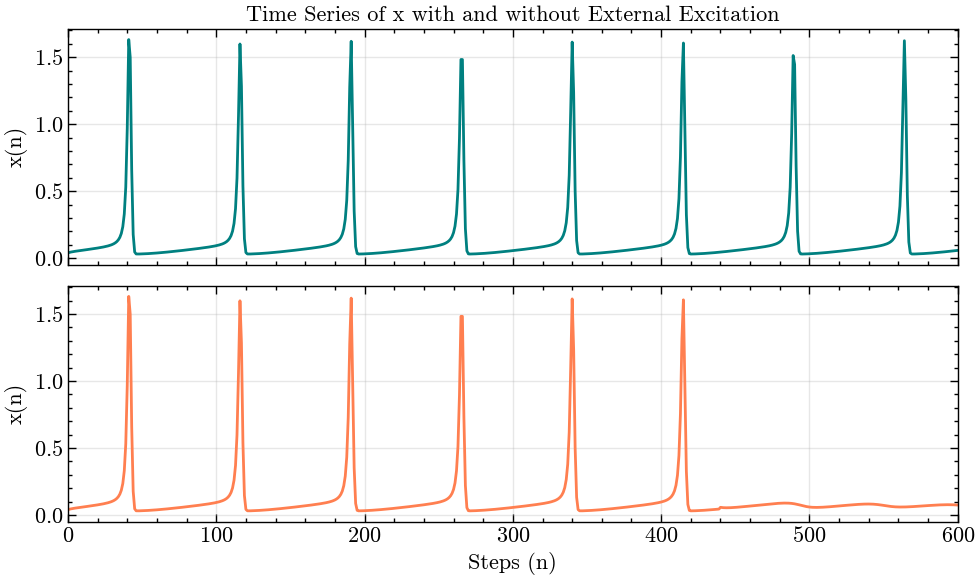

In [332]:
# Two-panel figure of time series of x and y
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(trajectory_LC[:, 0], color='teal')
ax1.set_ylabel('x(n)')
ax1.set_title('Time Series of x with and without External Excitation')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 600)

ax2.plot(trajectory_LC_ext[:, 0], color='coral')
ax2.set_xlabel('Steps (n)')
ax2.set_ylabel('x(n)')
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 600)

plt.tight_layout()
plt.show()

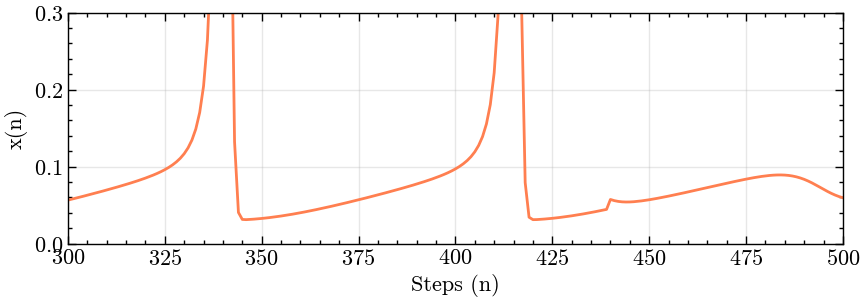

In [341]:
plt.figure(figsize=(10, 3))
plt.plot(trajectory_LC_ext[:, 0], color='coral')
plt.xlabel('Steps (n)')
plt.ylabel('x(n)')
plt.grid(alpha=0.3)
plt.xlim(300, 500)
plt.ylim(0., 0.3)
# plt.title('Time Series of x with External Excitation')
plt.show()

### 2.2.1 Bursting and chaos

Complicated dynamics also emerge as bursting and aperiodic solutions. Necessary conditions to occur:

1. single unestable fixed point (systems has sutonomous oscillations)

2. The activation-dependence of the recovery variable (parameter b in equation (1)) must be relatively small, such that f(x, y) in (1) is not substantially modified by the ongoing oscillations.

3. the unstable fixed point must be near x, y = 1, 1

In [356]:
# Define parameters
a_f9 = 0.89
b_f9 = 0.18
c_f9 = 0.28
k_f9 = 0.03

# Phase space with nullclines
x_for_nullX_f9 = np.linspace(0.02, 6., 100000)
x_for_nullY_f9 = np.linspace(0.04, 6., 1000)
dx_f9 = nullcline_x(x_for_nullX_f9, k=k_f9)
dy_f9 = nullcline_y(x_for_nullY_f9, a=a_f9, b=b_f9, c=c_f9)

# Intersection points
from scipy.optimize import fsolve
def equations(p):
    # Define parameters
    k = 0.03
    a = 0.89
    b = 0.18
    c = 0.28

    x, y = p
    return (np.log(x-k) - 2 * np.log(x) + x - y,
            (y*(a-1)+c)/(b) - x) 

initial_guesses = [(0.9, 0.9)]

fixed_points_f9 = []
for guess in initial_guesses:
    fixed_point = fsolve(equations, guess)
    fixed_points_f9.append(fixed_point)   

/tmp/ipykernel_42983/2971092805.py:3: RuntimeWarning: invalid value encountered in log
  y = np.log((x - k) / (x**2)) + x


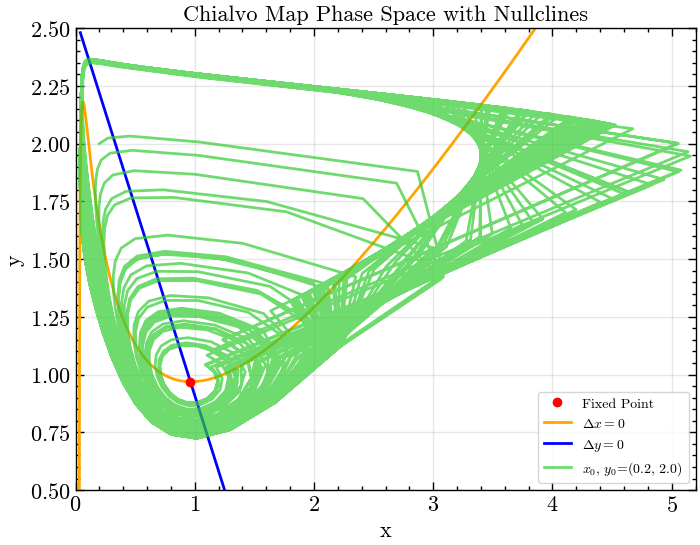

In [377]:
# Plot nullclines
plt.figure(figsize=(8, 6))

# Plot fixed points
for point in fixed_points_f9:
    plt.plot(point[0], point[1], 'ro', label='Fixed Point', zorder=5)

# Plot nullclines
plt.plot(x_for_nullX_f9, dx_f9, label=r'$\Delta x = 0$', color='orange')
plt.plot(x_for_nullY_f9, dy_f9, label=r'$\Delta y = 0$', color='blue')

# First trajectory without excitation
chialvo_f9 = ChialvoMap_ext(T=3000, a = a_f9, b = b_f9, c = c_f9, k = k_f9)
trajectory_f9 = chialvo_f9.run(x0=0.2, y0=2.0)
plt.plot(trajectory_f9[:, 0], trajectory_f9[:, 1], linestyle='-',
            label=r'$x_{0}, \, y_{0}$=' + f'(0.2, 2.0)', alpha=0.7, color='limegreen')

plt.title('Chialvo Map Phase Space with Nullclines')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(0.5, 2.5)
plt.xlim(0.0, 5.2)
plt.legend(frameon=True, fontsize=10)
plt.grid(alpha=0.3)
plt.show()

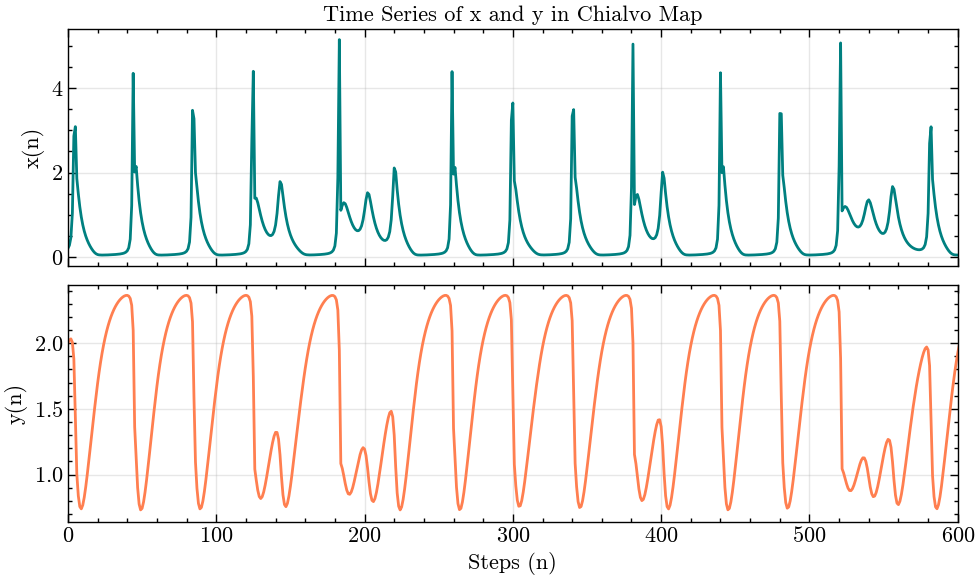

In [378]:
# Two-panel figure of time series of x and y
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(trajectory_f9[:, 0], color='teal')
ax1.set_ylabel('x(n)')
ax1.set_title('Time Series of x and y in Chialvo Map')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 600)

ax2.plot(trajectory_f9[:, 1], color='coral')
ax2.set_xlabel('Steps (n)')
ax2.set_ylabel('y(n)')
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 600)

plt.tight_layout()
plt.show()

## 3. Distributed Systems

It is useful to think, beside neural elements, also of models of forest-fire propagation assuming very large time space scale. With the appropiate coupling term the dynamics equations might be pictured as waves in a biological system or as combustion waves on a biological exitabel issue.

### 3.1 Vulnerability, unidirectional block and re-entry on a ring

Unidirectional block of propagation, leading to permanent circulation of waves in a
one-dimensional ring of excitable elements -> excitable tissues

$$
x^{i}_{n+1} = (1 - d)f(x^{i}_{n}) + \frac{d}{2}\left[f(x^{i+1}_{n}) + f(x^{i-1}_{n})\right]
$$

In [2]:
class Diffusion1DChialvo:
    def __init__(self, L=100, d=1.0, a=0.89, b=0.6, c=0.28, k=0.025, T=1000):
        self.L = L  # Length of the 1D lattice
        self.d = d  # Diffusion coefficient
        self.a = a
        self.b = b
        self.c = c
        self.k = k
        self.T = T

    def diffusion_step(self, x, y):
        # Apply periodic boundary conditions
        x_left = np.roll(x, 1)
        x_right = np.roll(x, -1)
        y_left = np.roll(y, 1)
        y_right = np.roll(y, -1)

        # Apply Chialvo map
        f_x, f_y = self.chialvo_step(x, y)
        f_x_l, f_y_l = self.chialvo_step(x_left, y_left)
        f_x_r, f_y_r = self.chialvo_step(x_right, y_right)

        x_new = (1 - self.d) * x + (self.d/2) * (f_x_l + f_x_r)
        return x_new,  f_y
    
    def chialvo_step(self, x, y):
        x_new = x**2 * np.exp(y - x) + self.k
        y_new = self.a * y - self.b * x + self.c

        return x_new, y_new
    
    def run(self, x0=None, y0=None, t_ext = None, x_ext=0.3, x_idx=None):
        # Initialize the state
        if x0 is None:
            x0 = np.zeros(self.L)

        if y0 is None:
            y0 = np.ones(self.L) * self.c / (1 - self.a)
        else:
            y0 = np.ones(self.L) * y0

        # Initialize y
        if len(x0) == 1:
            x = np.ones(self.L) * x0
        elif len(x0) == self.L:
            x = x0.copy()
        else:
            raise ValueError("x0 must be a scalar or an array of length L.")

        y = y0.copy()

        # Empty trajectory list
        self.trajectory = []
        # Append initial state
        self.trajectory.append(x)

        for t in range(1, self.T):
            if t_ext is not None and t == t_ext:
                if x_idx is not None:
                    x[x_idx] += x_ext
                else:
                    raise ValueError("x_idx must be provided when applying external excitation.")
            x, y = self.diffusion_step(x, y)
            self.trajectory.append(x)
        
        return np.array(self.trajectory)


In [596]:
# Define parameters for diffusion simulation
L_f11 = 200
a_f11 = 0.89
b_f11 = 0.6
c_f11 = 0.28
k_f11 = 0.02
T_f11 = 500

diff_1D_f11 = Diffusion1DChialvo(L=L_f11, d=0.4, a=a_f11, b=b_f11, c=c_f11, k=k_f11, T=T_f11)
# Initial condition: small perturbation at the beginning of the lattice
x0_f11 = np.zeros(L_f11)
x0_f11[0] = 1.1  # Small perturbation
trajectory_diff_f11 = diff_1D_f11.run(x0=x0_f11)

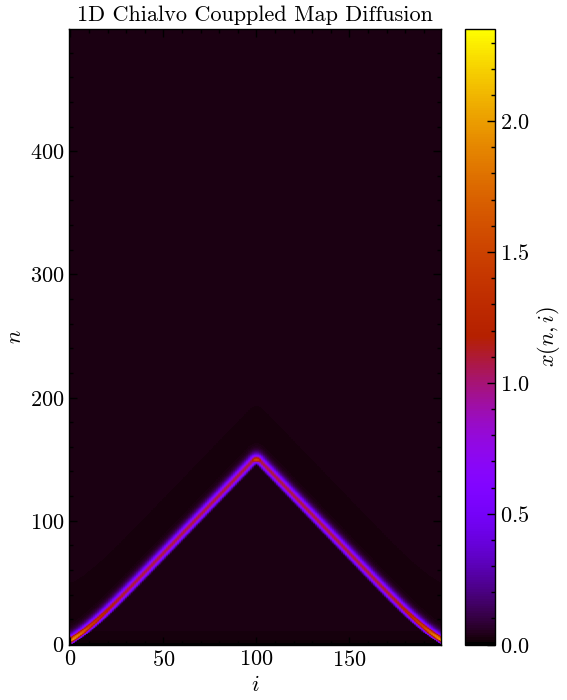

In [597]:
# Cmap of the diffusion process
plt.figure(figsize=(6, 8))
plt.imshow(trajectory_diff_f11, aspect='auto', cmap='gnuplot', origin='lower')
plt.colorbar(label=r'$x(n,i)$')
plt.xlabel(r'$i$')
plt.ylabel(r'$n$')
plt.title('1D Chialvo Couppled Map Diffusion')
plt.show()

In [598]:
# Define parameters for diffusion simulation
L_f11 = 200
a_f11 = 0.89
b_f11 = 0.6
c_f11 = 0.28
k_f11 = 0.02
T_f11 = 500

diff_1D_f11 = Diffusion1DChialvo(L=L_f11, d=0.4, a=a_f11, b=b_f11, c=c_f11, k=k_f11, T=T_f11)
# Initial condition: small perturbation at the beginning of the lattice
x0_f11 = np.zeros(L_f11)
x0_f11[0] = 0.3  # Small perturbation
trajectory_diff_f11 = diff_1D_f11.run(x0=x0_f11, t_ext=115, x_idx=125)

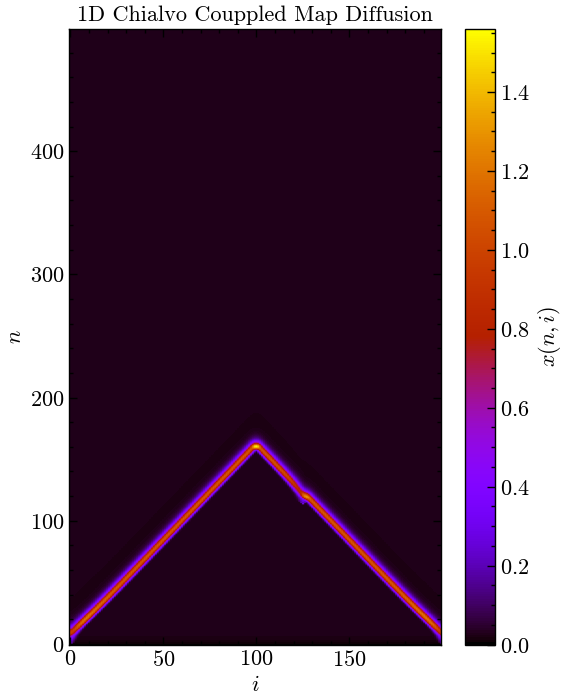

In [599]:
# Cmap of the diffusion process
plt.figure(figsize=(6, 8))
plt.imshow(trajectory_diff_f11, aspect='auto', cmap='gnuplot', origin='lower')
plt.colorbar(label=r'$x(n,i)$')
plt.xlabel(r'$i$')
plt.ylabel(r'$n$')
plt.title('1D Chialvo Couppled Map Diffusion')
plt.show()

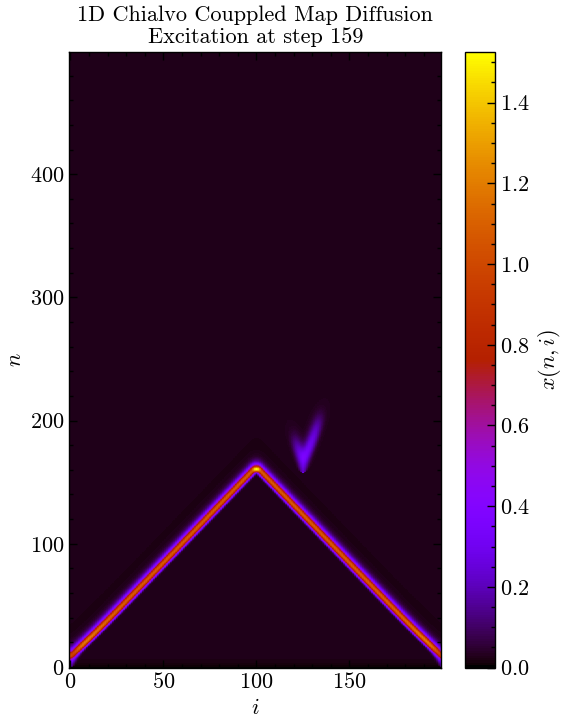

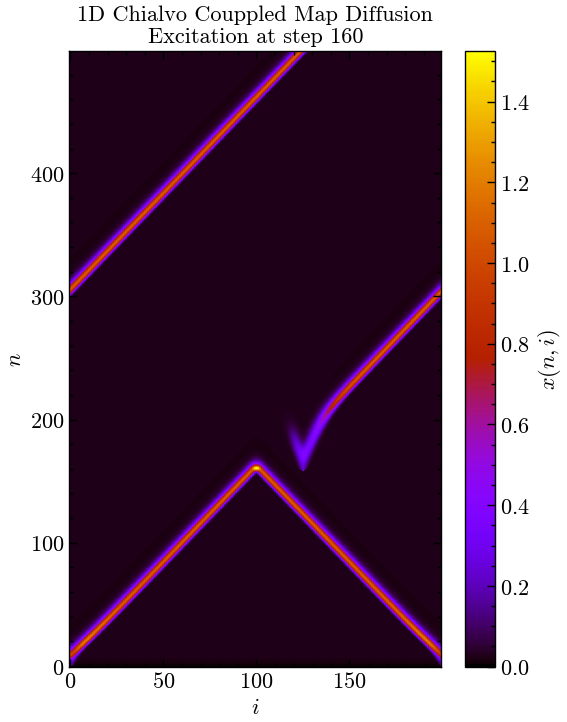

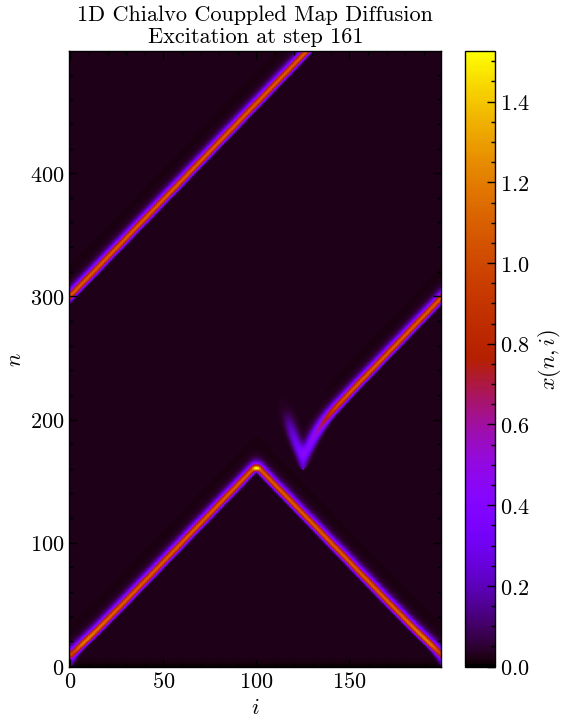

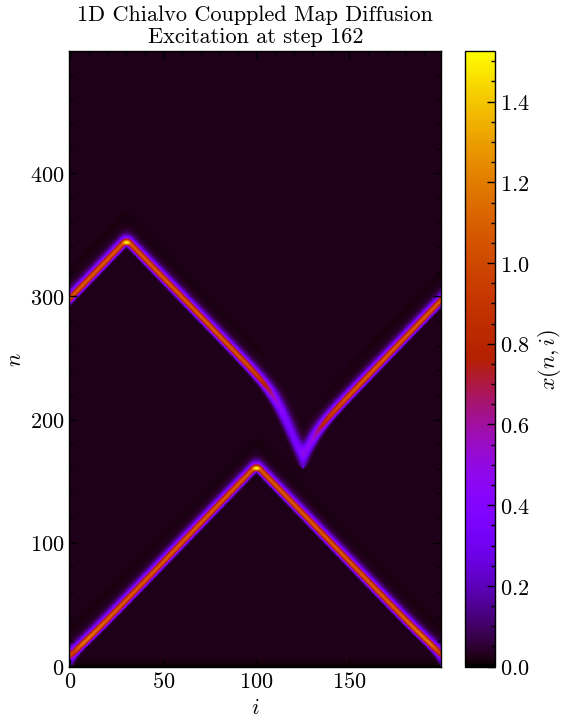

In [600]:
# Define parameters for diffusion simulation
L_f11 = 200
a_f11 = 0.89
b_f11 = 0.6
c_f11 = 0.28
k_f11 = 0.02
T_f11 = 500
x_idx_f11 = 125

for t_ext_f11 in range(159, 162 +1):

    diff_1D_f11 = Diffusion1DChialvo(L=L_f11, d=0.4, a=a_f11, b=b_f11, c=c_f11, k=k_f11, T=T_f11)
    # Initial condition: small perturbation at the beginning of the lattice
    x0_f11 = np.zeros(L_f11)
    x0_f11[0] = 0.3  # Small perturbation
    trajectory_diff_f11 = diff_1D_f11.run(x0=x0_f11, t_ext=t_ext_f11, x_idx=x_idx_f11)

    # Cmap of the diffusion process
    plt.figure(figsize=(6, 8))
    plt.imshow(trajectory_diff_f11, aspect='auto', cmap='gnuplot', origin='lower')
    plt.colorbar(label=r'$x(n,i)$')
    plt.xlabel(r'$i$')
    plt.ylabel(r'$n$')
    plt.title('1D Chialvo Couppled Map Diffusion' +
              f'\nExcitation at step {t_ext_f11}')
    plt.show()

- From 160 to 162 iteration a extrange unidirectional exiation appears and then, the reexcitation of the ring initiates at $x(0)$.

- Perturbation at 164 and so on generates a bidirectional wave but the left-right wave propagates slower. This delay is due to the fact that the wave propating from left to right is traveling trough nodes that does not recovered yet. 

    What does it mean? 
    The speed of progagation depends on coupling and aplitude if the x-variablem, therefore is a function of the recovery varible.

- Finally if the pertubation comes sooner theexcitation is not propagated , since the stimulus comes at a time whe nthe reacovery variable is still far from the equilibrium.

#### Case 1: Bidirectional wave propagation

In [566]:
def plot_tool(trajectory, ext_step=None):
    """Plot time series at a specific step and cmap of the diffusion process."""

    # Plot time series at a specific step
    plt.figure(figsize=(10, 6))
    plt.plot(trajectory[ext_step-1,:], color='coral', linewidth=2)
    plt.title(f'Time Series at Step n={ext_step-1}')
    plt.xlabel('i')
    plt.ylabel(r'$x(n, i)$')
    plt.xlim(0, 200)
    plt.ylim(0, 1.6)
    plt.grid(alpha=0.3)
    plt.show()

    # Plot cmap of the diffusion process
    plt.figure(figsize=(6, 8))
    plt.imshow(trajectory, aspect='auto', cmap='gnuplot', origin='lower')
    plt.colorbar(label=r'$x(n,i)$')
    plt.xlabel(r'$i$')
    plt.ylabel(r'$n$')
    plt.title('1D Chialvo Couppled Map Diffusion' +
            f'\nExcitation at step {ext_step}')
    plt.show()

In [ ]:
class AnimateTool:
    """"
    Class tool for creating a animated gif.
    """
    def __init__(self, trajectory):
        self.NT, self.NX = trajectory.shape
        self.trajectory = trajectory

    def animate(self, name='diffusion_animation.gif', frames=None):

        if frames is None:
            frames = self.NT

        fig, ax = plt.subplots(figsize=(10, 6))
        line, = ax.plot([], [], color='coral', linewidth=2)

        ax.set_xlim(0, self.NX)
        ax.set_ylim(0, 1.6)
        ax.set_xlabel('i')
        ax.set_ylabel(r'$x(n, i)$')
        ax.grid(alpha=0.3)

        title = ax.set_title("")

        # --- Animation function ---
        def init():
            line.set_data([], [])
            title.set_text("")
            return line, title

        def update(frame):
            y = self.trajectory[frame, :]
            line.set_data(np.arange(self.NX), y)
            title.set_text(f"Time Series at Step n={frame}")
            return line, title

        # --- Build animation ---
        anim = FuncAnimation(
            fig, update, frames=frames,
            init_func=init, interval=40, blit=True
        )
        # plt.show()
        plt.close()
        anim.save('figures/' + name, writer='pillow', fps=30)

        return anim

In [567]:
# Define parameters for diffusion simulation
L_f11 = 200
a_f11 = 0.89
b_f11 = 0.6
c_f11 = 0.28
k_f11 = 0.02
T_f11 = 500
x_idx_f11 = 125

diff_1D_f11_ext162 = Diffusion1DChialvo(L=L_f11, d=0.4, a=a_f11, b=b_f11, c=c_f11, k=k_f11, T=T_f11)
# Initial condition: small perturbation at the beginning of the lattice
x0_f11 = np.zeros(L_f11)
x0_f11[0] = 0.3  # Small perturbation
trajectory_diff_f11_ext162 = diff_1D_f11_ext162.run(x0=x0_f11, t_ext=162, x_idx=x_idx_f11, x_ext=0.3)

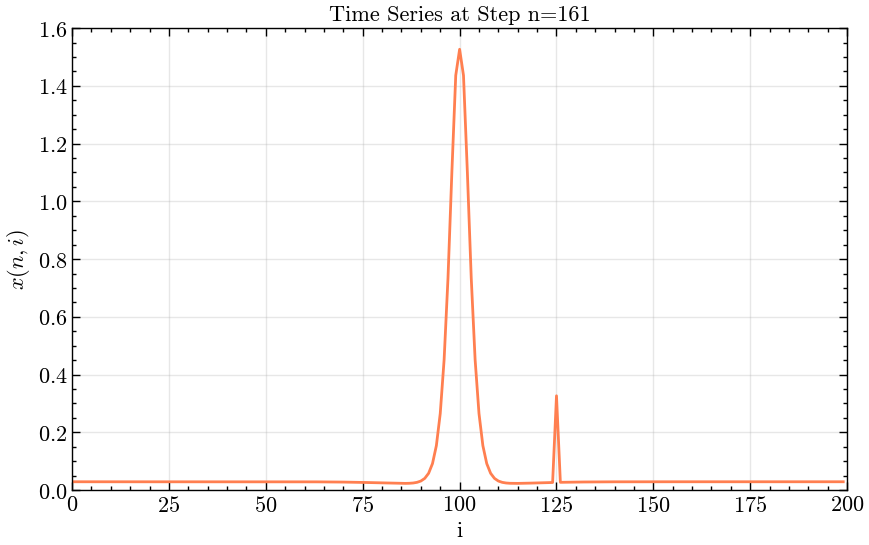

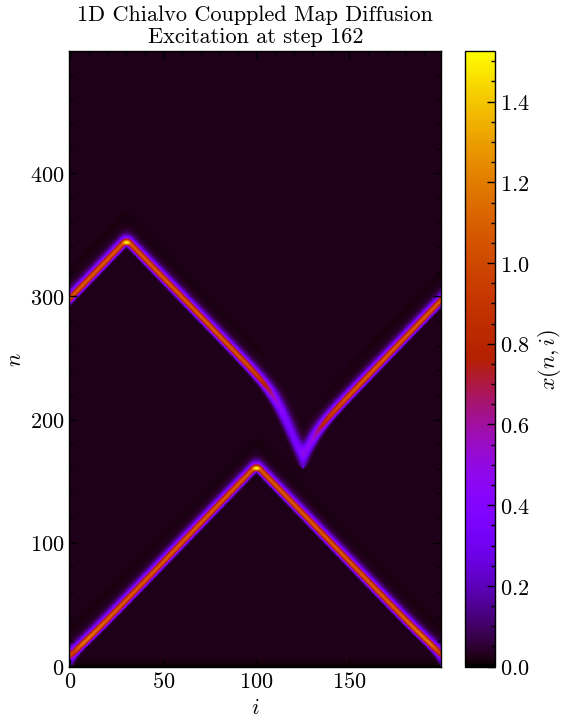

In [568]:
plot_tool(trajectory_diff_f11_ext162, ext_step=162)

In [515]:
ani_f11_ext162 = AnimateTool(trajectory_diff_f11_ext162)
ani_f11_ext162.animate(name='diffusion_animation_ext162.gif', frames=375)

#### Case 2: Onedirectional wave propagation

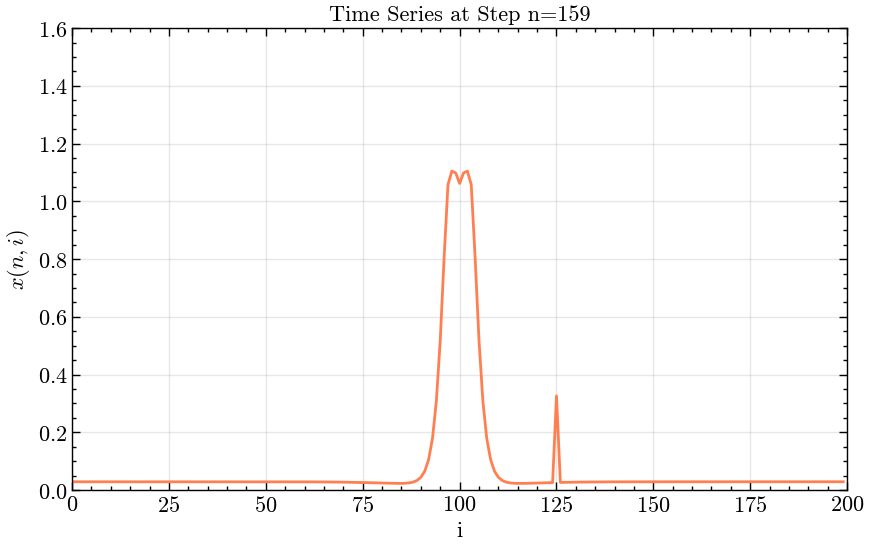

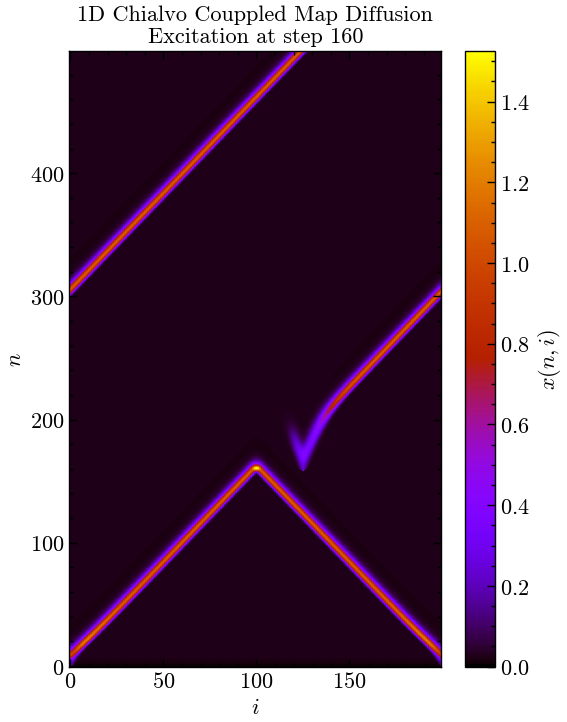

In [569]:
# Define parameters for diffusion simulation
L_f11 = 200
a_f11 = 0.89
b_f11 = 0.6
c_f11 = 0.28
k_f11 = 0.02
T_f11 = 500
x_idx_f11 = 125

# Run simulation
diff_1D_f11_ext160 = Diffusion1DChialvo(L=L_f11, d=0.4, a=a_f11, b=b_f11, c=c_f11, k=k_f11, T=T_f11)
# Initial condition: small perturbation at the beginning of the lattice
x0_f11 = np.zeros(L_f11)
x0_f11[0] = 0.3  # Small perturbation
trajectory_diff_f11_ext160 = diff_1D_f11_ext160.run(x0=x0_f11, t_ext=160, x_idx=x_idx_f11, x_ext=0.3)

# Plot
plot_tool(trajectory_diff_f11_ext160, ext_step=160)

In [508]:
ani_f11_ext160 = AnimateTool(trajectory_diff_f11_ext160)
ani_f11_ext160.animate(name='diffusion_animation_ext160.gif')

#### Case 3: No wave propagation

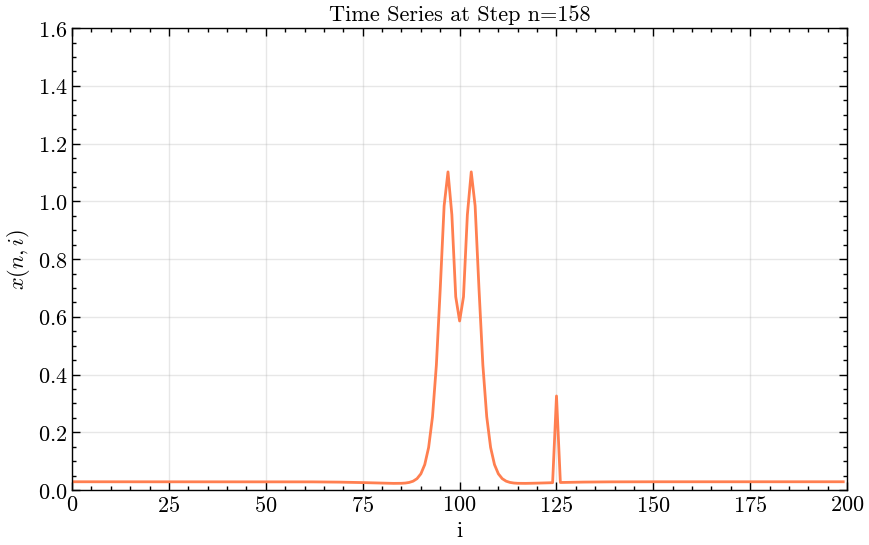

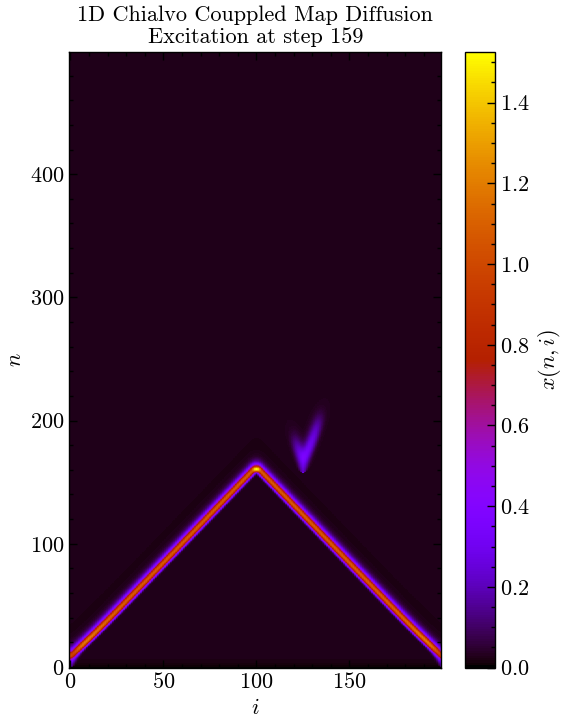

In [570]:
# Define parameters for diffusion simulation
L_f11 = 200
a_f11 = 0.89
b_f11 = 0.6
c_f11 = 0.28
k_f11 = 0.02
T_f11 = 500
x_idx_f11 = 125

# Run simulation
diff_1D_f11_ext159 = Diffusion1DChialvo(L=L_f11, d=0.4, a=a_f11, b=b_f11, c=c_f11, k=k_f11, T=T_f11)
# Initial condition: small perturbation at the beginning of the lattice
x0_f11 = np.zeros(L_f11)
x0_f11[0] = 0.3  # Small perturbation
trajectory_diff_f11_ext159 = diff_1D_f11_ext159.run(x0=x0_f11, t_ext=159, x_idx=x_idx_f11, x_ext=0.3)
# Plot
plot_tool(trajectory_diff_f11_ext159, ext_step=159)

In [512]:
ani_f11_ext159 = AnimateTool(trajectory_diff_f11_ext159)
ani_f11_ext159.animate(name='diffusion_animation_ext159.gif', frames=225)

### 3.2 Self-organized solutions in two-dimensional media

$$
x^{i,j}_{n+1} = (1 - d)f(x^{i,j}_{n}) + \frac{d}{4}\left[f(x^{i+1,j}_{n}) + f(x^{i-1,j}_{n}) + f(x^{i,j+1}_{n}) + f(x^{i,j-1}_{n})\right]
$$

In [17]:
class Diffusion2DChialvoOld:
    def __init__(self, L=100, d=1.0, a=0.89, b=0.6, c=0.28, k=0.025, T=1000):
        self.L = L  
        self.d = d  # Diffusion coefficient
        self.a = a
        self.b = b
        self.c = c
        self.k = k
        self.T = T

    def get_neighbors(self, i, j, x):
        # get Von Neumann neighbors with periodic boundary conditions
        left = x[i, (j - 1) % self.L]
        right = x[i, (j + 1) % self.L]
        up = x[(i - 1) % self.L, j]
        down = x[(i + 1) % self.L, j]
        return left, right, up, down

    def diffusion_step(self, x, y):
        for i in range(self.L):
            for j in range(self.L):
                # Get neighbors with periodic boundary conditions
                x_left, x_right, x_up, x_down = self.get_neighbors(i, j, x)
                y_left, y_right, y_up, y_down = self.get_neighbors(i, j, y)

                # Apply Chialvo map
                f_x, f_y = self.chialvo_step(x[i, j], y[i, j])
                f_x_l, f_y_l = self.chialvo_step(x_left, y_left)
                f_x_r, f_y_r = self.chialvo_step(x_right, y_right)
                f_x_u, f_y_u = self.chialvo_step(x_up, y_up)
                f_x_d, f_y_d = self.chialvo_step(x_down, y_down)

                # Update x with diffusion
                x[i, j] = (1 - self.d) * f_x + (self.d / 4) * (f_x_l + f_x_r + f_x_u + f_x_d)
                # Update y without diffusion
                y[i, j] = (1 - self.d) * f_y + (self.d / 4) * (f_y_l + f_y_r + f_y_u + f_y_d)
        return np.array(x, dtype=np.float64), np.array(y, dtype=np.float64)
    
    def chialvo_step(self, x, y):
        x_new = x**2 * np.exp(y - x) + self.k
        y_new = self.a * y - self.b * x + self.c

        return np.array(x_new, dtype=np.float64), np.array(y_new, dtype=np.float64)
    
    def run(self, x0=None, y0=None, t_ext = None, x_ext=0.3, x_idx_i=None, x_idx_j=None):
        # Initialize the state
        if x0 is None:
            x0 = np.zeros((self.L, self.L))

        if y0 is None:
            y0 = np.ones((self.L, self.L)) * self.c / (1 - self.a)
        else:
            y0 = np.ones((self.L, self.L)) * y0

        # Initialize y
        if len(x0) == 1:
            x = np.ones((self.L, self.L)) * x0

        elif len(x0) == self.L:
            x = x0.copy()
        else:
            raise ValueError("x0 must be a scalar or an array of length L.")

        y = y0.copy()

        # Empty trajectory lists
        self.xtrajectory = []
        self.ytrajectory = []
        # Append initial state
        self.xtrajectory.append(x.copy())
        self.ytrajectory.append(y.copy())


        for t in range(1, self.T):
            if t_ext is not None and t == t_ext:
                if x_idx_i is not None and x_idx_j is not None:
                    x[x_idx_i, x_idx_j] += x_ext
                else:
                    raise ValueError("x_idx_i and x_idx_j must be provided when applying external excitation.")
            x, y = self.diffusion_step(x, y)
            self.xtrajectory.append(x.copy())
            self.ytrajectory.append(y.copy())
        
        return np.array(self.xtrajectory), np.array(self.ytrajectory)

In [135]:
class Diffusion2DChialvo:
    def __init__(self, L=100, d=1.0, a=0.89, b=0.6, c=0.28, k=0.025, T=1000, bc='disipative'):
        self.L = L  
        self.d = d  # Diffusion coefficient
        self.a = a
        self.b = b
        self.c = c
        self.k = k
        self.T = T
        self.bc = bc


    def diffusion_step(self, x, y):
        # Apply Chialvo map
        f_x, f_y = self.chialvo_step(x, y)

        # Apply periodic boundary conditions to get neighbors 
        if self.bc == 'periodic':
            f_x_l = np.roll(f_x, 1, axis=1)
            f_x_r = np.roll(f_x, -1, axis=1)
            f_x_u = np.roll(f_x, 1, axis=0)
            f_x_d = np.roll(f_x, -1, axis=0)     
        elif self.bc == 'disipative':
            f_x_l = np.zeros_like(f_x)
            f_x_r = np.zeros_like(f_x)
            f_x_u = np.zeros_like(f_x)
            f_x_d = np.zeros_like(f_x)

            f_x_l[:, 1:] = f_x[:, :-1]
            f_x_r[:, :-1] = f_x[:, 1:]
            f_x_u[1:, :] = f_x[:-1, :]
            f_x_d[:-1, :] = f_x[1:, :]
        else:
            raise ValueError("Invalid boundary condition type. Use 'periodic' or 'disipative'.")

        x_new = (1 - self.d) * f_x + (self.d / 4) * (f_x_l + f_x_r + f_x_u + f_x_d)
        y_new = f_y

        return x_new, y_new    
    
    def chialvo_step(self, x, y):
        x_new = x**2 * np.exp(y - x) + self.k
        y_new = self.a * y - self.b * x + self.c

        return np.array(x_new), np.array(y_new)
    
    def run(self, x0=None, y0=None, t_ext = None, x_ext=0.3, x_idx_i=None, x_idx_j=None):
        # Initialize the state
        if x0 is None:
            x0 = np.zeros((self.L, self.L))

        if y0 is None:
            y0 = np.ones((self.L, self.L)) * self.c / (1 - self.a)
        else:
            y0 = np.ones((self.L, self.L)) * y0

        # Initialize y
        if len(x0) == 1:
            x = np.ones((self.L, self.L)) * x0
        elif len(x0) == self.L:
            x = x0.copy()
        else:
            raise ValueError("x0 must be a scalar or an array of length L.")

        y = y0.copy()

        # Empty trajectory list
        self.x_trajectory = []
        # Append initial state
        self.x_trajectory.append(x)

        # Empty y evolution list
        self.y_trajectory = []
        self.y_trajectory.append(y)
        
        for t in range(1, self.T):
            if t_ext is not None and t == t_ext:
                if x_idx_i is not None and x_idx_j is not None:
                    x[x_idx_i, x_idx_j] += x_ext
                else:
                    raise ValueError("x_idx_i and x_idx_j must be provided when applying external excitation.")
            x, y = self.diffusion_step(x, y)
            self.x_trajectory.append(x.copy())
            self.y_trajectory.append(y.copy())
        
        return np.array(self.x_trajectory), np.array(self.y_trajectory)

In [157]:
# Parameters
a_f13 = 0.89
b_f13 = 0.6
c_f13 = 0.26
k_f13 = 0.02
L_f13 = 100

# Nullclines
x_for_nullX_f13 = np.linspace(0.02, 4., 100000)
x_for_nullY_f13 = np.linspace(0.00, 4., 100000)
dx_f13 = nullcline_x(x_for_nullX_f13, k=k_f13)
dy_f13 = nullcline_y(x_for_nullY_f13, a=a_f13, b=b_f13, c=c_f13)

# Compute fixed points
fixed_points_f13 = []
guesses = [(0.025, 2.19)]

# Equations to solve
def equations(p):
    # Define parameters
    k = k_f13
    a = a_f13
    b = b_f13
    c = c_f13

    x, y = p
    return (np.log(x-k) - 2 * np.log(x) + x - y,
            (y*(a-1)+c)/(b) - x) 

for guess in guesses:
    fixed_point = fsolve(equations, guess)
    fixed_points_f13.append(fixed_point)
print("Fixed Points:", fixed_points_f13)

# Inital conditions for x
x0_f13 = np.zeros((L_f13, L_f13), dtype=np.float64)

for i in range(0, len(x0_f13)):
    x0_f13[:, i] = i * 0.0033

# Inital conditions for y
y0_f13 = np.zeros((L_f13, L_f13), dtype=np.float64)

for i in range(0, len(y0_f13)):
    y0_f13[i, :] = (2.22109753) - (i * 0.0066)

Fixed Points: [array([0.02613212, 2.22109753])]


/tmp/ipykernel_6090/2971092805.py:3: RuntimeWarning: divide by zero encountered in log
  y = np.log((x - k) / (x**2)) + x


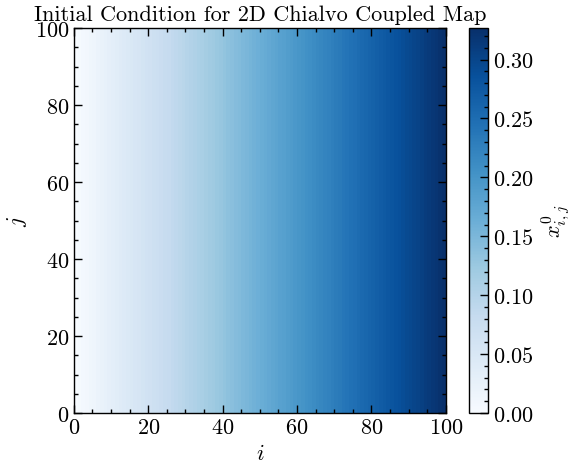

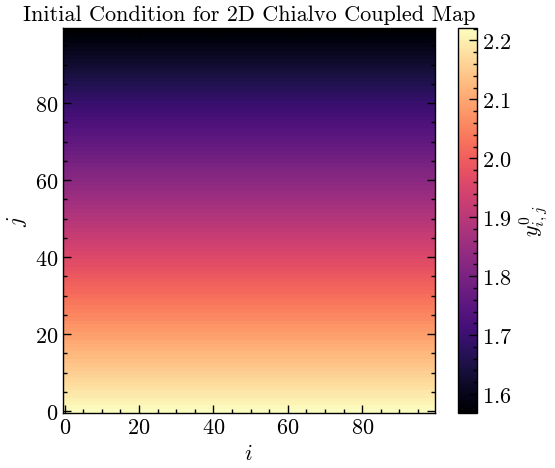

In [174]:
plt.figure(figsize=(6, 5))
plt.pcolormesh(x0_f13, cmap='Blues')
plt.colorbar(label=r'$x_{i,j}^0$')   
plt.xlabel(r'$i$')
plt.ylabel(r'$j$')
plt.title('Initial Condition for 2D Chialvo Coupled Map')
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(y0_f13, aspect='auto', cmap='magma', origin='lower')
plt.colorbar(label=r'$y_{i,j}^0$')   
plt.xlabel(r'$i$')
plt.ylabel(r'$j$')
plt.title('Initial Condition for 2D Chialvo Coupled Map')
plt.show()

In [163]:
# Run the 2D diffusion simulation
diff_2D_f13 = Diffusion2DChialvo(L=L_f13, d=0.4, a=a_f13, b=b_f13, c=c_f13, k=k_f13, T=400)
xtrajectory_diff_f13, ytrajectory_diff_f13 = diff_2D_f13.run(x0=x0_f13, y0=y0_f13)

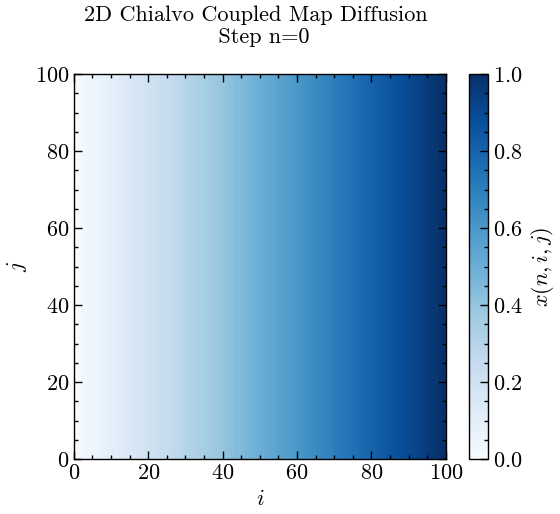

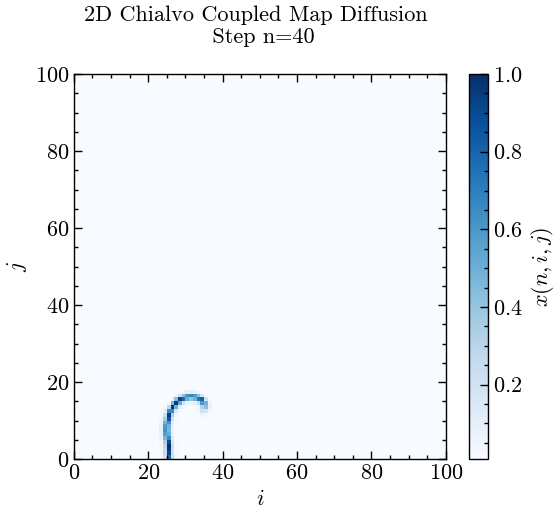

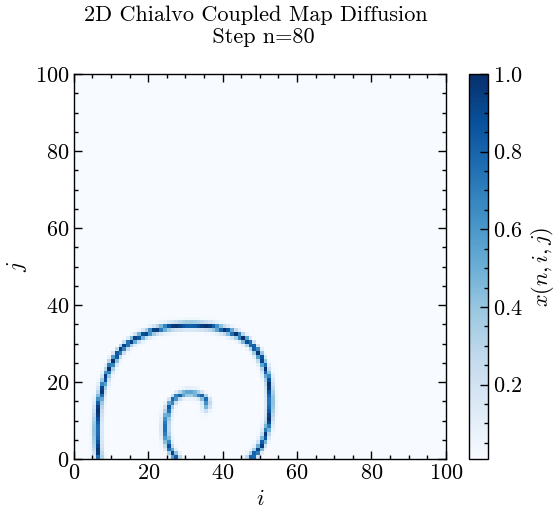

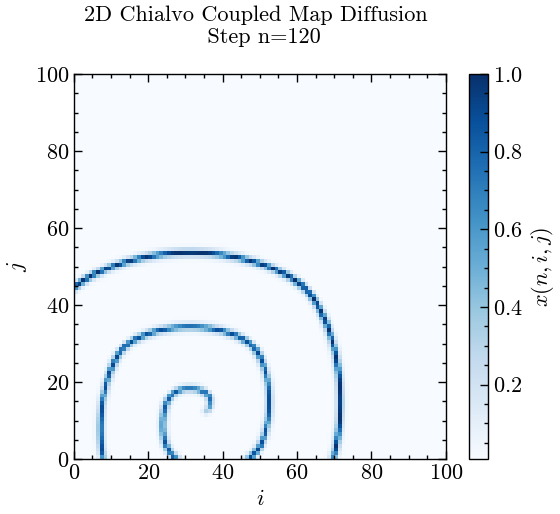

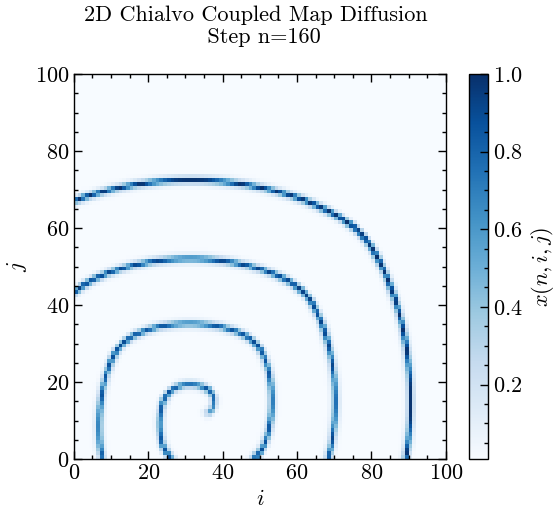

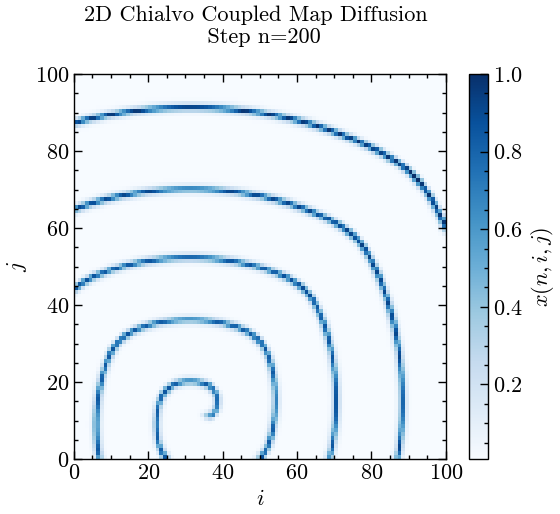

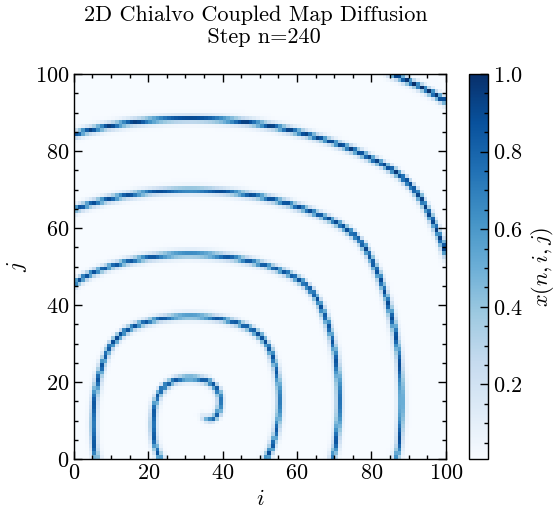

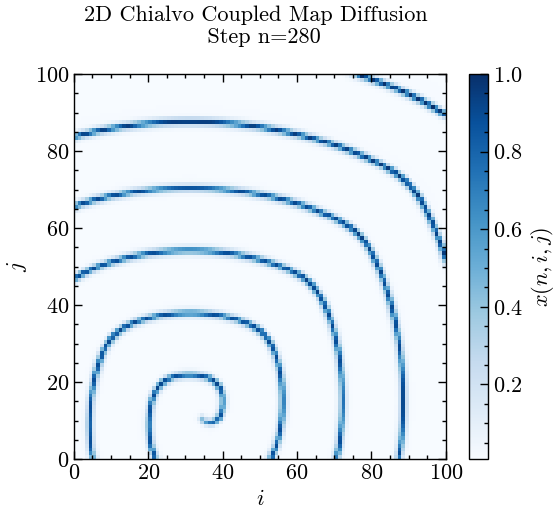

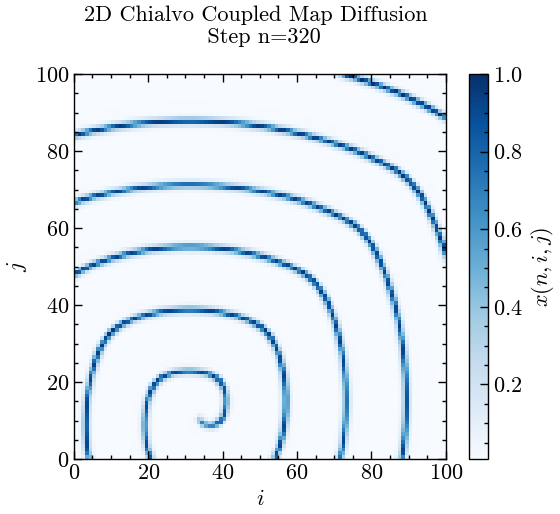

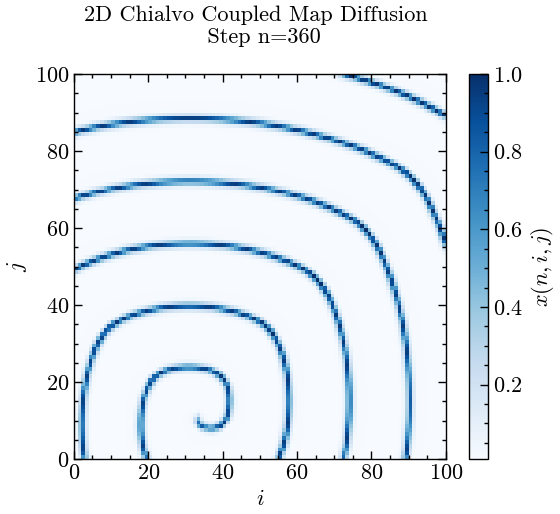

In [173]:
frames_to_plot = [i for i in range(0, 400, 40)]

for n in frames_to_plot:
    plt.figure(figsize=(6, 5))
    max_val = xtrajectory_diff_f13[n, :, :].max()
    plt.pcolormesh(xtrajectory_diff_f13[n, :, :]/max_val, cmap='Blues', shading='auto')
    plt.colorbar(label=r'$x(n,i,j)$')   
    plt.xlabel(r'$i$')
    plt.ylabel(r'$j$')
    plt.title(f'2D Chialvo Coupled Map Diffusion \n Step n={n}\n')
    plt.show()

In [ ]:
frames_to_plot = [i for i in range(0, 400, 40)]

for n in frames_to_plot:
    plt.figure(figsize=(6, 5))
    max_val = xtrajectory_diff_f13[n, :, :].max()
    plt.pcolormesh(xtrajectory_diff_f13[n, :, :]/max_val, cmap='Blues', shading='auto')
    plt.colorbar(label=r'$x(n,i,j)$')   
    plt.xlabel(r'$i$')
    plt.ylabel(r'$j$')
    plt.title(f'2D Chialvo Coupled Map Diffusion \n Step n={n}\n')
    plt.show()

In [192]:
class Animate2DTool:
    def __init__(self, xtrajectory, output_dir='figures', file_name='diffusion_2D_animation'):
        self.NT, self.NX, self.NY = xtrajectory.shape
        self.xtrajectory = xtrajectory
        self.output_dir = output_dir
        self.file_name = file_name

    def plot_for_animate(self, i):
        """
        """
        plt.figure(figsize=(6, 5))
        max_val = self.xtrajectory[i, :, :].max()
        plt.pcolormesh(self.xtrajectory[i, :, :]/max_val, cmap='Blues', shading='auto')
        plt.colorbar(label=r'$x_n^{i,j}$')   
        plt.xlabel(r'$i$')
        plt.ylabel(r'$j$')
        plt.title(f'2D Chialvo Coupled Map Diffusion \n Step n={i}\n')
        # plt.show()       

        # Save the figure frame
        plt.savefig(self.output_dir + f"/{self.file_name}" + ".{:03d}.png".format(i))   
        plt.close()
    
    def animate(self):
        """
        """
        # Create a directory for saving the figures and gift 
        if os.path.isdir(self.output_dir):
            print(f"Directory '{self.output_dir}/' already exists.")
        else:
            print(f"Directory '{self.output_dir}/' has been created.")
            os.mkdir(self.output_dir)

        print("Generating GIF...")
       
        # Create all images

        #start = t.time()

        n_cpu = mp.cpu_count()

        # Paralelize image generation
        pool = mp.Pool(processes = n_cpu)
        pool.map(self.plot_for_animate, range(1, self.NT + 1, 2))

        # for i in range(1, self.time_arr.shape[0] + 1):
        #     self.plot_for_animate(i)
        #end = t.time()
        #print(f'execution time is {end - start} s')

        #Read all the generated figures to create the movie

        #Define the input directory
        images_input = self.output_dir + f"/{self.file_name}.***.png"

        # Collect the images
        imgs = (Image.open(f) for f in sorted(glob.glob(images_input)))

        img = next(imgs)

        #Define the output directory
        imgif_output = self.output_dir + f"/{self.file_name}.gif"

        # Save the GIF
        img.save(fp = imgif_output, format="GIF", append_images=imgs,\
                save_all=True, duration = 100, loop = 0, fps=60)
                    
        return print(f"The movie was generated correctly in '{self.output_dir}/' as:", f"{self.file_name}.gif")

In [193]:
# Instantiate and run the animation tool
ani_2D_f13 = Animate2DTool(xtrajectory_diff_f13, output_dir='figures/spiral_f13', file_name='diffusion_2D_animation_f13')
ani_2D_f13.animate()

Directory 'figures/spiral_f13/' already exists.
Generating GIF...
The movie was generated correctly in 'figures/spiral_f13/' as: diffusion_2D_animation_f13.gif


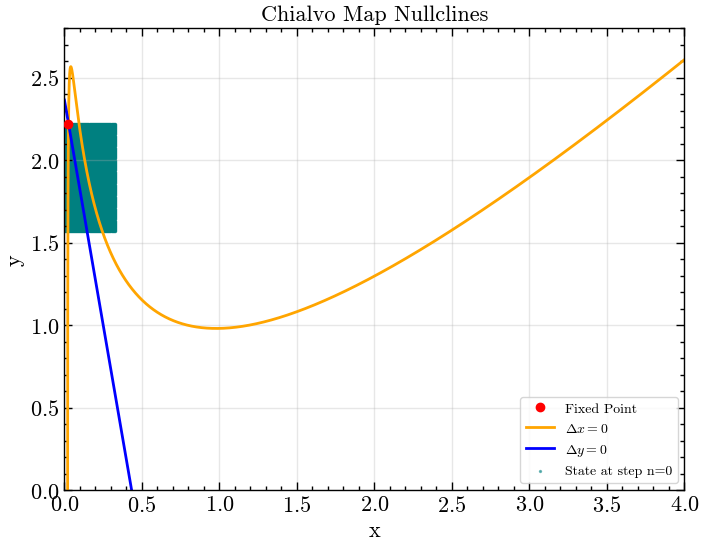

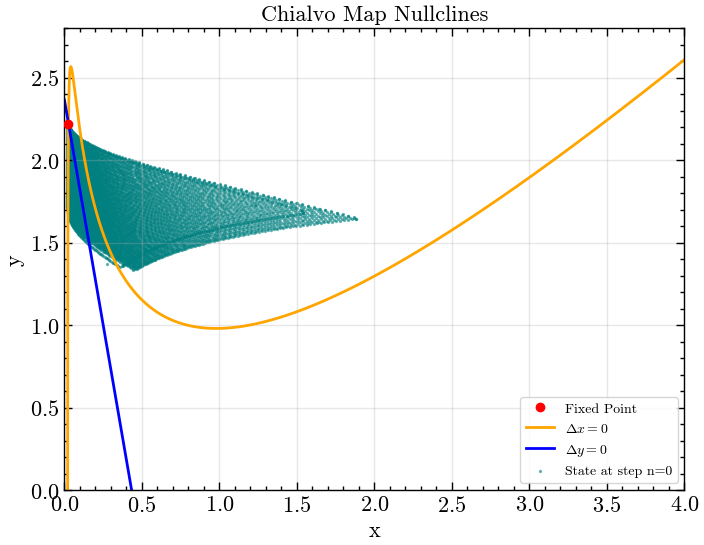

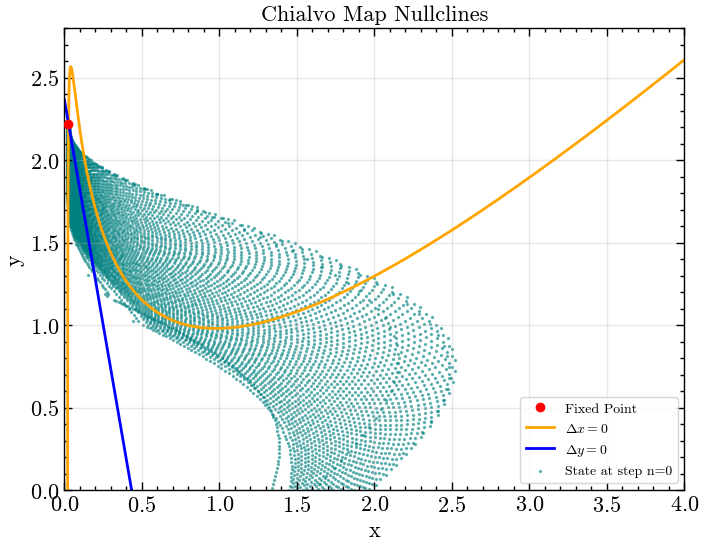

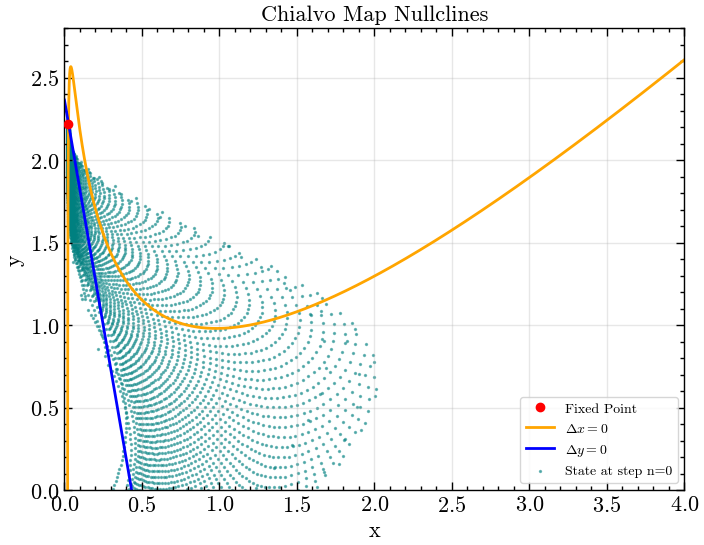

In [168]:
for n in range(0, 8, 2):
    plt.figure(figsize=(8, 6))

    # Plot fixed points
    for point in fixed_points_f13:
        plt.plot(point[0], point[1], 'ro', label='Fixed Point', zorder=5)
    # Plot nullclines
    plt.plot(x_for_nullX_f13, dx_f13, label=r'$\Delta x = 0$', color='orange')
    plt.plot(x_for_nullY_f13, dy_f13, label=r'$\Delta y = 0$', color='blue')

    # Plot sactter data
    x_data = xtrajectory_diff_f13[n, :, :].flatten()
    y_data = ytrajectory_diff_f13[n, :, :].flatten()  
    plt.scatter(x_data, y_data, s=2, color='teal', alpha=0.5, label='State at step n=0')

    plt.title('Chialvo Map Nullclines')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(0.0, 4.0)
    plt.ylim(0.0, 2.8)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(alpha=0.3)
    plt.show()